# M&A Prediction from Pre-Announcement News Sentiment

**Goal:** Predict whether a company will be acquired based on news coverage patterns *before* the public announcement.

### Why news instead of stock prices?
- News signals can surface strategic shifts, financial stress, or industry consolidation trends before markets react
- Free, scalable data source via GDELT + SEC EDGAR full-text search (no API key required)

### Scope: large ($1B+) deals only
`ma_events.csv` is now built from two S&P Global exports pre-filtered to **deal value >= $1B**,
spanning **2016-2026** (`code/clean_ma_events.py`, `--min-deal-value-usd 1e9`). Restricting to large
deals means targets are much more likely to be well-covered public companies, which is exactly the
regime where name-based news search has enough recall to be informative.

### Pipeline
```
ma_events.csv   ->   GDELT + EDGAR    ->  local persistent cache  ->  NLP feature layer   ->  models
($1B+, 2016-26)     (by company name)    data/raw/news/*.csv        VADER + FinBERT +      (LogReg, RF)
                                                                     TF-IDF log-odds +
                                                                     NMF topics
```

News is no longer scraped inline in this notebook. `code/download_news_ma_events.py` fetches GDELT +
SEC EDGAR articles for a sample of events and appends them to a **local, resumable, gitignored cache**
(`data/raw/news/ma_event_news.csv`) — re-running it only fetches events/windows not already cached, so
the (slow, rate-limited) scraping cost is paid once. This notebook just loads that cache. Google News
RSS was dropped from the source mix: it has no historical date filter, so it cannot serve the
2016-2025 announcement windows used here.

### Experimental Design
| Sample | Company | News Window | Label |
|--------|---------|-------------|-------|
| Positive | M&A target | 90 -> 7 days before announcement | 1 |
| Negative | Same company | 270 -> 187 days before announcement | 0 |

The **blackout of 7 days** avoids leakage from deal rumor news appearing right before announcement.
The **180-day shift** creates a "quiet period" baseline for the same company.

### Deeper NLP (this pass)
The first pass used only VADER (a fixed sentiment lexicon) and a hand-written M&A keyword regex. This
pass adds three model-based / data-driven layers, still with **no generative LLM**:
1. **FinBERT** (`ProsusAI/finbert`) — a finance-tuned BERT classifier — for sentence-level sentiment, replacing the general-purpose VADER lexicon with one trained on financial text.
2. **TF-IDF + log-odds ratio** (Monroe et al. informative-prior log-odds) — discovers which words/phrases actually separate the *pre* window from the *baseline* window in this corpus, instead of relying on a fixed keyword list.
3. **NMF topic modeling** — unsupervised topic decomposition of the headline corpus, giving each event-window a topic-loading vector (e.g. "regulatory/antitrust", "earnings", "activist/strategic review").

In [1]:
import subprocess, sys
for pkg in ['vaderSentiment', 'scikit-learn', 'transformers', 'torch']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)
print('✓ Dependencies ready')

✓ Dependencies ready


In [2]:
import os, re, time, json, warnings, random, sys
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import NMF
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, confusion_matrix
)
from scipy import stats as scipy_stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120})

# ── Paths ──────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path('..').resolve()
CODE_DIR     = PROJECT_ROOT / 'code'
EVENTS_PATH  = PROJECT_ROOT / 'data' / 'raw' / 'events' / 'ma_events.csv'
NEWS_CACHE   = PROJECT_ROOT / 'data' / 'raw' / 'news' / 'ma_event_news.csv'   # built by download_news_ma_events.py
FEATURES_OUT = PROJECT_ROOT / 'data' / 'interim' / 'ma_news_features.csv'

# Reuse the same helpers the standalone scraper uses, so window definitions can't drift
sys.path.insert(0, str(CODE_DIR))
from download_news_ma_events import clean_name, get_window_dates

# ── Experiment config (must match the scraping run in download_news_ma_events.py) ──
LOOKBACK_DAYS   = 90    # total lookback window length
BLACKOUT_DAYS   = 7     # exclude last N days before announcement
NEGATIVE_SHIFT  = 180   # shift back for negative samples
RANDOM_SEED     = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('✓ Imports complete')

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Imports complete


## 1. Data Overview

In [3]:
events = pd.read_csv(EVENTS_PATH, parse_dates=['announcement_date', 'close_date'])

print(f'Total M&A events:             {len(events):>8,}')
print(f'Date range:                   {events["announcement_date"].min().date()} → {events["announcement_date"].max().date()}')
print(f'Events with target ticker:    {events["target_ticker"].notna().sum():>8,}  ({events["target_ticker"].notna().mean():.1%})')
print(f'Events with acquirer ticker:  {events["acquirer_ticker"].notna().sum():>8,}  ({events["acquirer_ticker"].notna().mean():.1%})')
print(f'Events with deal value:       {events["deal_value_usd"].notna().sum():>8,}')
print(f'\nStatus distribution:')
print(events['deal_status'].value_counts().to_string())

Total M&A events:                2,673
Date range:                   2016-06-24 → 2026-06-16
Events with target ticker:         113  (4.2%)
Events with acquirer ticker:     1,020  (38.2%)
Events with deal value:          2,673

Status distribution:
deal_status
Completed    2479
Announced     194


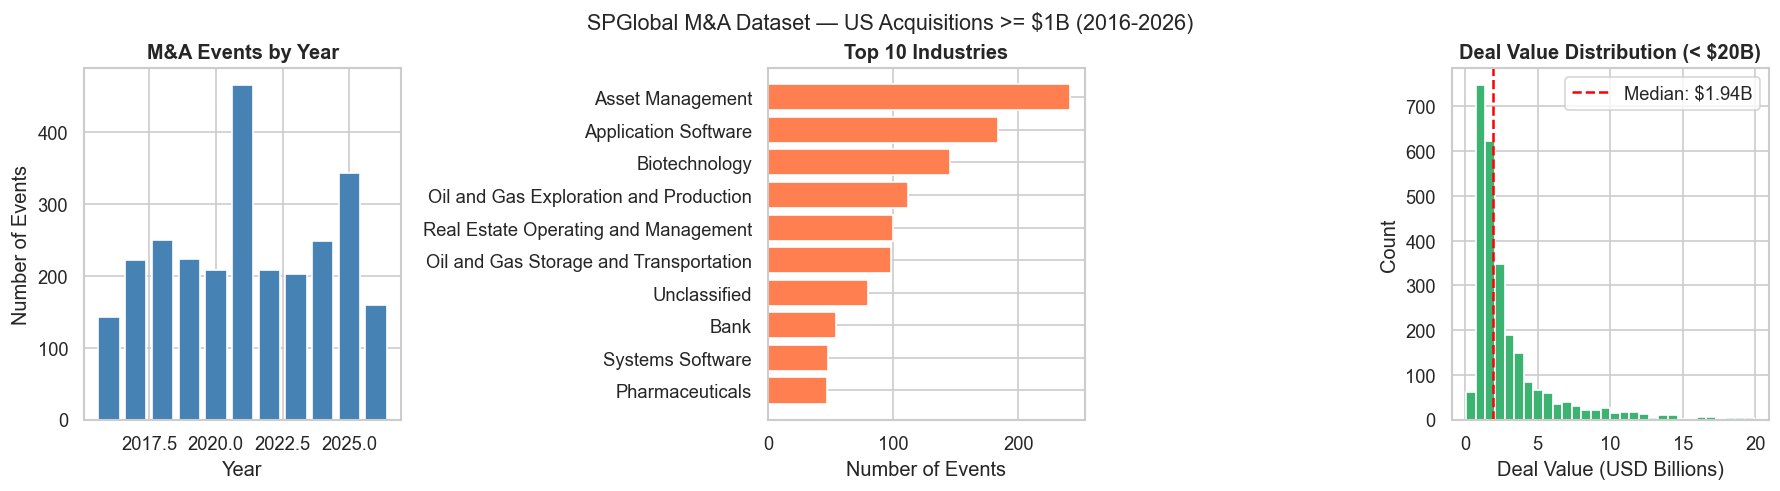

Deals with no ticker (private/unlisted targets): 2,560
→ Using company NAME for news search covers all 2,673 events


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Events per year
events['year'] = events['announcement_date'].dt.year
year_cnt = events['year'].value_counts().sort_index()
axes[0].bar(year_cnt.index, year_cnt.values, color='steelblue', edgecolor='white')
axes[0].set_title('M&A Events by Year', fontweight='bold')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Number of Events')

# Top industries
top_ind = events['primary_industry'].value_counts().head(10)
axes[1].barh(top_ind.index[::-1], top_ind.values[::-1], color='coral', edgecolor='white')
axes[1].set_title('Top 10 Industries', fontweight='bold')
axes[1].set_xlabel('Number of Events')

# Deal value distribution (all events are already >= $1B by construction)
dv = events['deal_value_usd'].dropna() / 1e9
axes[2].hist(dv[dv < 20], bins=30, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Deal Value Distribution (< $20B)', fontweight='bold')
axes[2].set_xlabel('Deal Value (USD Billions)')
axes[2].set_ylabel('Count')
axes[2].axvline(dv.median(), color='red', linestyle='--', label=f'Median: ${dv.median():.2f}B')
axes[2].legend()

plt.tight_layout()
plt.suptitle('SPGlobal M&A Dataset — US Acquisitions >= $1B (2016-2026)', fontsize=13, y=1.02)
plt.show()
print(f'Deals with no ticker (private/unlisted targets): {events["target_ticker"].isna().sum():,}')
print(f'→ Using company NAME for news search covers all {len(events):,} events')

## 2. News Data (from local persistent cache)

News is fetched by the standalone, resumable script `code/download_news_ma_events.py`, **not** inline
in this notebook. It queries two complementary free, date-filterable sources per event window:

| Source | Coverage | Date Filter | Auth |
|--------|----------|-------------|------|
| **GDELT** | Global news media | ✓ date range | none |
| **SEC EDGAR full-text search** | 8-K / SC-TO / SC-13D / SC-13G / DEFM14A filings mentioning the company | ✓ date range | none |

(Google News RSS was dropped — it has no historical date filter, so it cannot serve 2016-2025
announcement windows and would only burn request budget.)

Each run samples events from `ma_events.csv` ($1B+, 2016-2026) and scrapes two 90-day windows:
- **`pre`** (label=1): `[announcement − 97d, announcement − 7d]`
- **`baseline`** (label=0): the same window shifted back 180 days — a "quiet period" for the same company

Results append to `data/raw/news/ma_event_news.csv` (gitignored, regenerable per `DATA.md`).
**Re-running the script only fetches (transaction_id, window) pairs not already in the cache** — safe
to stop, resume, or top up with more events at any time without re-paying GDELT's rate limit.

```bash
# from the repo root, run more coverage whenever needed:
python code/download_news_ma_events.py --n-events 300 --seed 42
```

The cells below just **load** whatever is currently in the cache.

In [5]:
# Reuse the exact same fetchers the standalone scraper uses (single source of truth for
# query construction / rate limiting), for optional ad-hoc spot-checks in this notebook.
from download_news_ma_events import fetch_gdelt, fetch_edgar, RateLimiter

MA_KW_RE = re.compile(
    r'\b(merger|acqui|takeover|buyout|buy.?out|strategic|bid|offer|'
    r'private equity|stake|transaction|bought|sold|purchase)\b',
    re.IGNORECASE
)

print('✓ Scrapers imported from code/download_news_ma_events.py')
print('  GDELT:     free, historical, exact-phrase -> any-language fallback')
print('  SEC EDGAR: free, full-text search over M&A-relevant filings (8-K/SC-TO/13D/13G/DEFM14A)')

✓ Scrapers imported from code/download_news_ma_events.py
  GDELT:     free, historical, exact-phrase -> any-language fallback
  SEC EDGAR: free, full-text search over M&A-relevant filings (8-K/SC-TO/13D/13G/DEFM14A)


In [6]:
# ── Connectivity test + demo ──────────────────────────────────────────────
limiter = RateLimiter(1.2)

print('Testing GDELT connectivity...')
test_arts = fetch_gdelt(limiter, 'Microsoft', '2023-01-01', '2023-01-31', max_records=3)
if test_arts:
    print(f'✓ GDELT reachable — {len(test_arts)} articles for Microsoft (2023-01)')
else:
    print('✗ GDELT returned 0 — possible connectivity issue or VPN block.')

print()

# Step 2: demo with a large ($1B+) target from the event set
demo_event = events[events['target_name'].notna()].iloc[100]
demo_name  = demo_event['target_name']
demo_ann   = pd.Timestamp(demo_event['announcement_date'])
demo_start, demo_end = get_window_dates(demo_ann, 'pre', LOOKBACK_DAYS, BLACKOUT_DAYS, NEGATIVE_SHIFT)

print(f'Demo company: {demo_name}   (deal value ${demo_event["deal_value_usd"]/1e9:.1f}B)')
print(f'Announced:    {demo_ann.date()}')
print(f'Window:       {demo_start} → {demo_end}')
print(f'Query name:   "{clean_name(demo_name)}"')
print()

gdelt_arts = fetch_gdelt(limiter, demo_name, demo_start, demo_end)
edgar_arts = fetch_edgar(demo_name, demo_start, demo_end)

print(f'GDELT:  {len(gdelt_arts):3d} articles')
print(f'EDGAR:  {len(edgar_arts):3d} filings')

for a in (gdelt_arts + edgar_arts)[:4]:
    print(f"  [{a['source']:6s}][{a.get('date','------')[:8]}] {a['title'][:75]}")

Testing GDELT connectivity...


✗ GDELT returned 0 — possible connectivity issue or VPN block.

Demo company: Two Harbors Investment Corp.   (deal value $1.3B)
Announced:    2026-03-19
Window:       2025-12-12 → 2026-03-12
Query name:   "Two Harbors Investment"



GDELT:   27 articles
EDGAR:   20 filings
  [gdelt ][20260308] Head to Head Comparison : Two Harbors Investments ( NYSE : TWO ) & MFA Fina
  [gdelt ][20260303] A Look At Two Harbors Investment ( TWO ) Valuation After Recent Share Price
  [gdelt ][20260301] UWM Holdings CEO Sells Nearly 2M Shares For $9M
  [gdelt ][20260301] UWM Holdings CEO Sells 1 . 27M Shares for $6 . 5 Million


In [7]:
def load_cache() -> pd.DataFrame:
    if NEWS_CACHE.exists():
        return pd.read_csv(NEWS_CACHE, dtype=str).fillna('')
    return pd.DataFrame(columns=['transaction_id', 'window', 'label', 'company_name', 'title', 'date', 'domain', 'source', 'url'])

print('✓ Cache loader defined —', NEWS_CACHE.relative_to(PROJECT_ROOT))

✓ Cache loader defined — data/raw/news/ma_event_news.csv


In [8]:
# ── Preview the event pool the standalone scraper targets ─────────────────
# (mirrors select_events() in code/download_news_ma_events.py)
events_pool = events[
    (events['target_name'].notna()) &
    (events['deal_status'].isin(['Completed', 'Announced']))
].copy()

cache_preview = load_cache()
cached_ids = set(cache_preview['transaction_id']) if not cache_preview.empty else set()

print(f'Eligible $1B+ events (2016-2026):  {len(events_pool):,}')
print(f'Events already in local cache:     {len(cached_ids):,}')
print(f'Not yet scraped:                   {len(events_pool) - len(cached_ids):,}')

Eligible $1B+ events (2016-2026):  2,673
Events already in local cache:     675
Not yet scraped:                   1,998


In [9]:
# ── Load the persistent news cache (built by code/download_news_ma_events.py) ─────────
# No inline scraping here anymore — this just loads whatever has been cached so far.
# To add more coverage (safe to re-run, resumes from where it left off):
#     python code/download_news_ma_events.py --n-events 300

cache_df = load_cache()
if cache_df.empty:
    raise RuntimeError(
        'No cached news found. From the repo root, run:\n'
        '  python code/download_news_ma_events.py --n-events 300\n'
        'then re-run this cell.'
    )

print(f'✓ Cache: {len(cache_df):,} rows  ({cache_df["transaction_id"].nunique()} events)')
articles_only = cache_df[cache_df['title'] != '']
print(f'  Articles with text: {len(articles_only):,}')
print(f'  Events with ≥1 article: {articles_only["transaction_id"].nunique()}')
if 'source' in articles_only.columns:
    print(f'\n  Breakdown by source:')
    print(articles_only['source'].value_counts().to_string())

✓ Cache: 12,887 rows  (675 events)
  Articles with text: 12,071
  Events with ≥1 article: 329

  Breakdown by source:
source
gdelt    8542
edgar    3529


## 3. NLP Layer 1 — VADER Sentiment (baseline)

**VADER** (Valence Aware Dictionary and sEntiment Reasoner) is a rule-based, general-purpose lexicon
scorer. It's fast and needs no training data, but it wasn't built for financial text — words like
"aggressive" or "leverage" carry finance-specific connotations VADER doesn't know about. We keep it
as a fast baseline and then add deeper layers below (FinBERT, data-driven terms, momentum, filings).

**Source split (important fix):** SEC EDGAR "articles" in the cache are not prose — they're
auto-generated strings like `[8-K] COMPANY NAME (CIK 0001234) filed 2020-08-11`. Scoring that string
with a sentiment model is meaningless noise (it also pollutes the TF-IDF/topic layers below with
company-identity boilerplate — see §3c/§3d). So **all sentiment/text-mining NLP layers (VADER,
FinBERT, log-odds terms, NMF topics) run on GDELT headlines only**; EDGAR filings still carry real
signal, just structured, and are turned into filing-type/frequency features in §3e instead.

- Returns a **compound score** in [-1, 1]: negative → positive
- We also flag any headline matching a fixed M&A keyword regex (`MA_KW_RE`)

**Noise filter (fix):** GDELT is queried by exact company name, which also pulls in algorithmically-generated financial spam (13F/holdings-change bots, price-target/rating bots, market-research-report mills) that fires for every public company on a schedule, independent of M&A activity. A content-based regex (not label-conditioned) drops these before scoring.

In [10]:
sia = SentimentIntensityAnalyzer()

def score(title: str) -> dict:
    if not title or not str(title).strip():
        return {'compound': 0.0, 'pos': 0.0, 'neg': 0.0, 'neu': 1.0, 'has_ma_kw': 0}
    s = sia.polarity_scores(str(title))
    s['has_ma_kw'] = int(bool(MA_KW_RE.search(str(title))))
    return s

news_df = load_cache()

# ── Source split ────────────────────────────────────────────────────────
# EDGAR rows are auto-generated filing stubs, not prose (see markdown above) -- route
# them to structured filing-type features in §3e instead of sentiment scoring.
edgar_df = news_df[(news_df['source'] == 'edgar') & (news_df['title'].str.strip() != '')].copy()
gdelt_df = news_df[(news_df['source'] == 'gdelt') & (news_df['title'].str.strip() != '')].copy()

# ── Institutional/analyst-bot noise filter ──────────────────────────────────
# GDELT's "exact company name" query pulls in a lot of algorithmically-generated financial
# content -- 13F/holdings-change bots ("Sells 47,684 Shares of..."), analyst price-target/
# rating bots, and market-research-report spam ("Global ... Market 2020 by Technology"). These
# fire for every public company on a schedule regardless of M&A activity, so they dilute
# rather than inform the corpus. Flag+drop them with a template regex (content-based, applied
# identically to both windows -- not conditioned on label).
NOISE_RE = re.compile(
    r'('
    r'\bShares\b.{0,40}\b(Sold|Bought|Acquired|Cut|Lowered|Raised|Boosted|Purchased)\b|'
    r'\b(Sells|Buys|Acquires|Cuts|Lowers|Raises|Boosts|Purchases)\b.{0,40}\bShares\b|'
    r'\bHoldings (in|of)\b|\bPosition (in|of)\b|\bStake (in|of)\b|'
    r'\bPosition (Lowered|Raised|Boosted|Cut)\b|'
    r'\bPrice Target\b|\bPT from\b|\bAverage (Price )?Target\b|'
    r'\bRating (Upgraded|Downgraded|Reiterated|Lowered|Raised)\b|'
    r'\bShort Interest\b|\bInstitutional Investor\b|\bHedge Fund\b|'
    r'\bAverage Recommendation\b|\bModerate Buy\b|\b13F\b|'
    r'\bQ[1-4]\s?20\d\d Earnings\b|\bEarnings (Call )?Transcript\b|\bEarnings Snapshot\b|'
    r'\bMarket (Report|Size|Share|Growth|Trends|Forecast|Challenges|Outlook)\b|'
    r'\bGlobal Market\b|\bIndustry Forecast\b|\bTop Players\b|\bMarket 20\d\d\b|'
    r'\bMakes New Investment\b|\bTakes .{0,20}Position\b'
    r')',
    re.IGNORECASE,
)
# A short, manually-audited list of domains that are ~100% templated financial-bot content
# in this corpus (institutional 13F/holdings-change bots, market-research-report mills) --
# found by inspecting the highest-volume GDELT domains (see conversation history / DATA.md).
# Applied identically regardless of label.
JUNK_DOMAINS = {
    'dailypolitical.com', 'wkrb13.com', 'themarketsdaily.com', 'tickerreport.com',
    'theenterpriseleader.com', 'modernreaders.com', 'openpr.com', 'insidermonkey.com',
}
is_noise = gdelt_df['title'].str.contains(NOISE_RE, regex=True) | gdelt_df['domain'].isin(JUNK_DOMAINS)
print(f'Institutional/analyst-bot noise filter: dropping {is_noise.sum():,} of {len(gdelt_df):,} '
      f'GDELT headlines ({is_noise.mean():.1%}, balanced across windows: '
      f'{gdelt_df.groupby("window").apply(lambda g: g["title"].str.contains(NOISE_RE, regex=True).mean()).to_dict()})')
valid = gdelt_df[~is_noise].copy()

scores  = valid['title'].apply(score)
sent_df = pd.concat([valid.reset_index(drop=True), pd.DataFrame(scores.tolist())], axis=1)
sent_df['label'] = sent_df['label'].astype(int)

print(f'\nScored {len(sent_df):,} GDELT headlines (of {len(news_df):,} cached rows; '
      f'{len(edgar_df):,} EDGAR filings routed to structured features in §3e instead)')
print('\nMean sentiment by window (GDELT news only, noise-filtered):')
print(sent_df.groupby('window')[['compound', 'pos', 'neg', 'has_ma_kw']].mean().round(4))

Institutional/analyst-bot noise filter: dropping 1,463 of 8,542 GDELT headlines (17.1%, balanced across windows: {'baseline': 0.10267753201396973, 'pre': 0.1031316223216388})



Scored 7,079 GDELT headlines (of 12,887 cached rows; 3,529 EDGAR filings routed to structured features in §3e instead)

Mean sentiment by window (GDELT news only, noise-filtered):
          compound     pos     neg  has_ma_kw
window                                       
baseline    0.1024  0.0931  0.0384     0.0213
pre         0.0861  0.0852  0.0418     0.0274


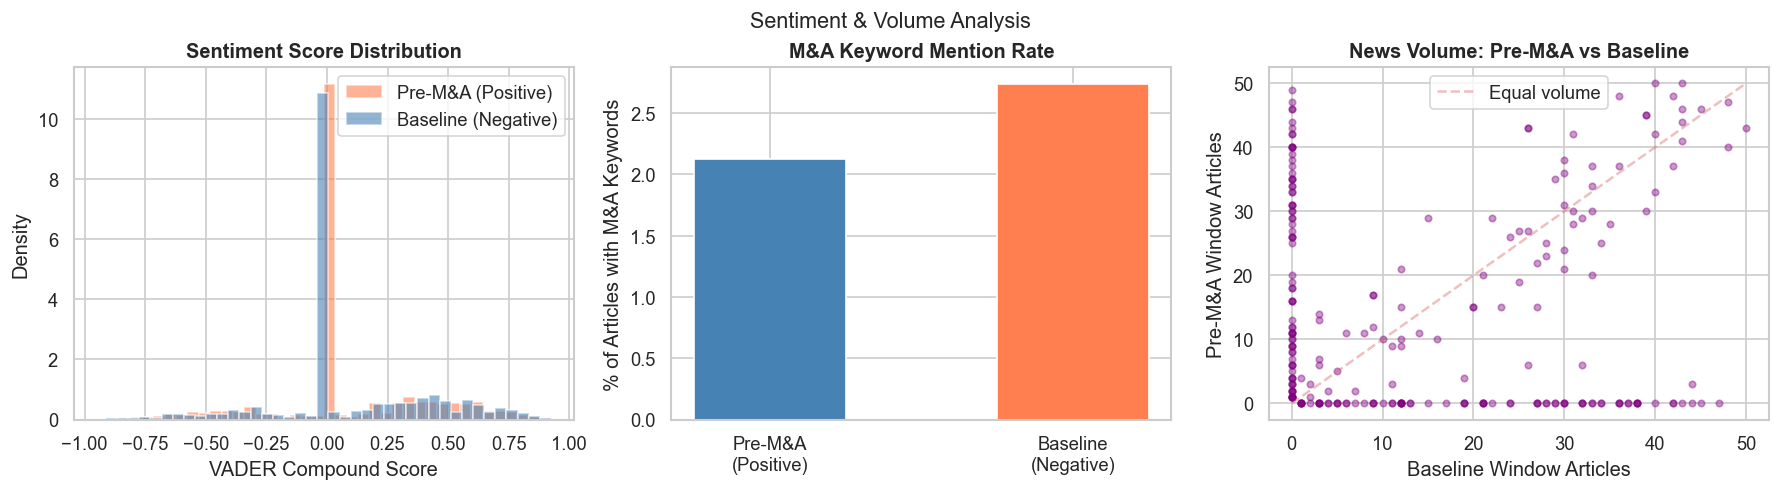

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Sentiment distribution
for window, color, lbl in [('pre', 'coral', 'Pre-M&A (Positive)'),
                             ('baseline', 'steelblue', 'Baseline (Negative)')]:
    d = sent_df[sent_df['window'] == window]['compound']
    axes[0].hist(d, bins=40, alpha=0.6, color=color, label=lbl, density=True)
axes[0].set_title('Sentiment Score Distribution', fontweight='bold')
axes[0].set_xlabel('VADER Compound Score')
axes[0].set_ylabel('Density')
axes[0].legend()

# M&A keyword rate
kw_rate = sent_df.groupby('window')['has_ma_kw'].mean() * 100
colors_bar = ['coral' if w == 'pre' else 'steelblue' for w in kw_rate.index]
axes[1].bar(kw_rate.index, kw_rate.values, color=colors_bar, edgecolor='white', width=0.5)
axes[1].set_title('M&A Keyword Mention Rate', fontweight='bold')
axes[1].set_ylabel('% of Articles with M&A Keywords')
axes[1].set_xticklabels(['Pre-M&A\n(Positive)', 'Baseline\n(Negative)'])

# Article volume comparison
cnt = sent_df.groupby(['transaction_id', 'window']).size().unstack(fill_value=0)
if 'pre' in cnt.columns and 'baseline' in cnt.columns:
    axes[2].scatter(cnt['baseline'], cnt['pre'], alpha=0.4, color='purple', s=15)
    mx = cnt.max().max()
    axes[2].plot([0, mx], [0, mx], 'r--', alpha=0.4, label='Equal volume')
    axes[2].set_title('News Volume: Pre-M&A vs Baseline', fontweight='bold')
    axes[2].set_xlabel('Baseline Window Articles')
    axes[2].set_ylabel('Pre-M&A Window Articles')
    axes[2].legend()

plt.tight_layout()
plt.suptitle('Sentiment & Volume Analysis', fontsize=13, y=1.02)
plt.show()

## 3b. NLP Layer 2 — FinBERT (finance-tuned sentiment)

VADER is a general lexicon; it has no notion that "leverage," "activist," or "antitrust" carry
different weight in financial headlines than in everyday text. **FinBERT** (`ProsusAI/finbert`) is a
BERT model fine-tuned on financial text for 3-class sentiment (positive/negative/neutral). It runs
fully locally (no API calls, no generative LLM) via `transformers`.

We score every cached headline and define `finbert_compound = P(positive) − P(negative)`, the same
shape as VADER's compound score, so the two are directly comparable feature-by-feature.

In [12]:
from transformers import pipeline

print('Loading FinBERT (ProsusAI/finbert) — local, runs once per session...')
finbert = pipeline('text-classification', model='ProsusAI/finbert', top_k=None, truncation=True, device=-1)

def finbert_score_batch(titles: list[str], batch_size: int = 32) -> pd.DataFrame:
    rows = []
    texts = [t if t and str(t).strip() else '.' for t in titles]
    for i in tqdm(range(0, len(texts), batch_size), desc='FinBERT'):
        out = finbert(texts[i:i + batch_size], batch_size=batch_size)
        for scores in out:
            rows.append({s['label']: s['score'] for s in scores})
    return pd.DataFrame(rows)

finbert_scores = finbert_score_batch(sent_df['title'].tolist())
sent_df['finbert_positive'] = finbert_scores['positive'].values
sent_df['finbert_negative'] = finbert_scores['negative'].values
sent_df['finbert_neutral']  = finbert_scores['neutral'].values
sent_df['finbert_compound'] = sent_df['finbert_positive'] - sent_df['finbert_negative']

print(f'\nScored {len(sent_df):,} headlines with FinBERT')
print('\nMean FinBERT sentiment by window:')
print(sent_df.groupby('window')[['finbert_compound', 'finbert_positive', 'finbert_negative']].mean().round(4))
print('\nMean VADER vs FinBERT compound by window (for comparison):')
print(sent_df.groupby('window')[['compound', 'finbert_compound']].mean().round(4))

Loading FinBERT (ProsusAI/finbert) — local, runs once per session...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 54947.21it/s]

FinBERT:   0%|          | 0/222 [00:00<?, ?it/s]

FinBERT:   0%|          | 1/222 [00:00<00:42,  5.23it/s]

...

FinBERT:  99%|█████████▊| 219/222 [00:46<00:00,  4.29it/s]

FinBERT:  99%|█████████▉| 220/222 [00:46<00:00,  4.23it/s]

FinBERT: 100%|█████████▉| 221/222 [00:46<00:00,  3.84it/s]

FinBERT: 100%|██████████| 222/222 [00:46<00:00,  4.73it/s]


Scored 7,079 headlines with FinBERT

Mean FinBERT sentiment by window:
          finbert_compound  finbert_positive  finbert_negative
window                                                        
baseline             0.087            0.2162            0.1292
pre                  0.075            0.2101            0.1351

Mean VADER vs FinBERT compound by window (for comparison):
          compound  finbert_compound
window                              
baseline    0.1024             0.087
pre         0.0861             0.075


## 3c. NLP Layer 3 — TF-IDF + Log-Odds Distinctive Terms (data-driven, not hand-written)

`MA_KW_RE` above is a fixed keyword list someone wrote down in advance. Instead, we let the corpus
tell us which words actually separate the *pre*-announcement window from the *baseline* window,
using the **informative-Dirichlet-prior log-odds-ratio** (Monroe, Colaresi & Quinn, 2008) — a
standard way to rank terms by class-distinctiveness that corrects for frequency (rare words don't
spuriously dominate) better than a raw log-odds or chi-square test would.

For each unigram/bigram $w$: $z_w = \dfrac{\delta_w}{\sqrt{\mathrm{Var}(\delta_w)}}$ where $\delta_w$
is the prior-smoothed log-odds of $w$ appearing in *pre* vs *baseline* headlines. Large $|z_w|$ = more
distinctive.

**Company-name masking (fix):** the *pre* and *baseline* windows are the same company at two points
in time, so every headline in both windows already mentions that company's name — a prolific company
(lots of press either way) would otherwise dominate the term counts with its own name/ticker, which
is a company identifier, not a generalizable M&A signal. Before vectorizing, each headline has its own
company's name tokens (from `clean_name`) blanked out, so the surviving distinctive terms have to be
genuinely shared content words across companies.

**Caveat (by design, not an oversight):** the terms below are still mined from the *entire* cached corpus,
across all events. Using the resulting `distinctive_term_ratio` feature in the classifier is therefore
not strictly train/test-isolated — it's an exploratory feature, flagged here and again in the
Limitations section. A leakage-safe version would refit this per CV fold.

In [13]:
TOKEN_PATTERN = r"(?u)\b[a-zA-Z]{3,}\b"

# ── Mask each headline's own company name out before vectorizing ──────────
# Without this, "distinctive terms" are dominated by which *company* happens to have
# lots of coverage in one window (e.g. a company name like "avidity" or "stericycle")
# rather than genuinely cross-company M&A language.
from functools import lru_cache

@lru_cache(maxsize=None)
def _company_mask_pattern(company_name: str):
    words = [w for w in clean_name(company_name).split() if len(w) >= 3]
    if not words:
        return None
    return re.compile(r'\b(' + '|'.join(re.escape(w) for w in words) + r')\b', re.IGNORECASE)

def _mask_company(row):
    pat = _company_mask_pattern(row['company_name'])
    return pat.sub(' ', str(row['title'])) if pat else str(row['title'])

sent_df['title_masked'] = sent_df.apply(_mask_company, axis=1)

count_vec = CountVectorizer(ngram_range=(1, 2), stop_words='english', min_df=5, max_df=0.5,
                             token_pattern=TOKEN_PATTERN)
X_counts = count_vec.fit_transform(sent_df['title_masked'])
vocab = count_vec.get_feature_names_out()

pre_mask  = (sent_df['window'] == 'pre').values
base_mask = (sent_df['window'] == 'baseline').values

counts_pre  = np.asarray(X_counts[pre_mask].sum(axis=0)).ravel()
counts_base = np.asarray(X_counts[base_mask].sum(axis=0)).ravel()
n_pre, n_base = counts_pre.sum(), counts_base.sum()

# Background (informative) prior: each word's overall frequency, scaled to a modest total pseudo-count
alpha0 = 1000.0
background = (counts_pre + counts_base) / (counts_pre.sum() + counts_base.sum())
alpha_w = background * alpha0

def log_odds_z(y_i, y_j, n_i, n_j, a_w, a0):
    delta = (np.log((y_i + a_w) / (n_i + a0 - y_i - a_w))
             - np.log((y_j + a_w) / (n_j + a0 - y_j - a_w)))
    variance = 1.0 / (y_i + a_w) + 1.0 / (y_j + a_w)
    return delta / np.sqrt(variance)

z_scores = log_odds_z(counts_pre, counts_base, n_pre, n_base, alpha_w, alpha0)

logodds_df = pd.DataFrame({
    'term': vocab, 'z_score': z_scores, 'count_pre': counts_pre, 'count_baseline': counts_base,
}).sort_values('z_score', ascending=False)

print('Top 15 terms distinctive of the PRE-M&A window (company names masked out):')
print(logodds_df.head(15)[['term', 'z_score', 'count_pre', 'count_baseline']].to_string(index=False))
print('\nTop 15 terms distinctive of the BASELINE (quiet-period) window:')
print(logodds_df.tail(15).sort_values('z_score')[['term', 'z_score', 'count_pre', 'count_baseline']].to_string(index=False))

SIG_Z = 2.0
distinctive_terms = logodds_df.loc[logodds_df['z_score'].abs() >= SIG_Z, 'term'].tolist()
print(f'\n{len(distinctive_terms)} terms pass |z| >= {SIG_Z} and will feed `distinctive_term_ratio`')

_distinctive_pattern = (
    re.compile(r'\b(' + '|'.join(re.escape(t) for t in distinctive_terms) + r')\b', re.IGNORECASE)
    if distinctive_terms else None
)
sent_df['has_distinctive_term'] = sent_df['title_masked'].apply(
    lambda t: int(bool(_distinctive_pattern.search(str(t)))) if _distinctive_pattern else 0
)

Top 15 terms distinctive of the PRE-M&A window (company names masked out):
              term  z_score  count_pre  count_baseline
          vaccines 4.260666         48              12
companies vaccines 4.155495         45              11
              spac 3.740598         28               2
             women 3.393474         39              13
           opinion 3.268403         25               5
              self 3.253205         22               3
            forbes 3.163315         21               3
            delays 3.163315         21               3
            friday 3.134793         30               9
           trailer 3.118717         20               1
              list 3.077215         31              10
           richest 3.047437         19               1
               feb 2.973503         18               1
              ties 2.968185         22               5
              time 2.909498         47              22

Top 15 terms distinctive of the BASELINE (qu

## 3d. NLP Layer 4 — NMF Topic Modeling

Sentiment alone collapses a headline to one number. **Topic modeling** captures *what a headline is
about* — e.g. an antitrust/regulatory story reads very differently from an earnings-beat story, even
at similar sentiment. We fit **NMF** (non-negative matrix factorization) on TF-IDF vectors of the
**company-name-masked** headline corpus (same masking as §3c, for the same reason — otherwise topics
are company clusters, not content clusters) — the standard, fast, sklearn-native alternative to LDA
for short text — and use each headline's topic-loading vector as additional features, aggregated
(mean) per event-window.

In [14]:
N_TOPICS = 8

tfidf_vec = TfidfVectorizer(ngram_range=(1, 2), stop_words='english', min_df=5, max_df=0.5,
                             token_pattern=TOKEN_PATTERN)
X_tfidf = tfidf_vec.fit_transform(sent_df['title_masked'])

nmf = NMF(n_components=N_TOPICS, init='nndsvda', random_state=RANDOM_SEED, max_iter=400)
topic_loadings = nmf.fit_transform(X_tfidf)

topic_terms = tfidf_vec.get_feature_names_out()
print(f'NMF topics (top terms per topic, {N_TOPICS} topics, company names masked):')
for k in range(N_TOPICS):
    top_idx = nmf.components_[k].argsort()[::-1][:8]
    print(f'  Topic {k}: ' + ', '.join(topic_terms[i] for i in top_idx))

for k in range(N_TOPICS):
    sent_df[f'topic_{k}'] = topic_loadings[:, k]

NMF topics (top terms per topic, 8 topics, company names masked):
  Topic 0: watch, companies, watch companies, companies vaccines, vaccines, research, companies research, regulation
  Topic 1: market, global, growth, analysis, report, forecast, billion, cagr
  Topic 2: quarter, results, financial, reports, financial results, second, second quarter, quarter financial
  Topic 3: news, com, world, june, calendar, daily, june news, calendar events
  Topic 4: stock, nasdaq, earnings, stock market, price, stock price, nyse, today
  Topic 5: new, data, york, new york, solar, state, open, mexico
  Topic 6: stocks, best, buy, stocks buy, energy, oil, wall, street
  Topic 7: announces, partners, board, quarterly, partners announces, distribution, offering, public


## 3e. NLP Layer 5 — Within-Window Momentum & EDGAR Filing Structure

Two more signals that don't fit the "one sentiment number per headline" mold:

1. **Momentum inside the window.** Deal rumors typically build as the announcement approaches, then
   go dark during the 7-day blackout. If that's real, coverage inside the 90-day *pre* window should
   skew *late* (more articles, more sentiment drift, just before the blackout) relative to the
   quiet-period *baseline* window, which has no announcement to build toward. For each article we
   compute its relative position inside its own (`transaction_id`, `window`) date range (0 = window
   start, 1 = window end, using the official boundaries from `get_window_dates`, not just the min/max
   date actually observed), then aggregate two per-window features: `late_share` (fraction of articles
   in the final third of the window) and `sentiment_trend` (slope of VADER compound vs. relative
   position).
2. **EDGAR filing structure**, used as counts/rates instead of sentiment (see §3 — an EDGAR "headline"
   is an auto-generated filing stub, not prose). Filing types other than routine `8-K`s (e.g.
   `DEFM14A`, `SC-13D/G`, `SC-TO`) are direct regulatory evidence of an ownership change or merger
   process step, so filing-type mix is a legitimate, non-textual M&A signal.

In [15]:
## ── Momentum features (GDELT) ──────────────────────────────────────────────
sent_df = sent_df.merge(events[['transaction_id', 'announcement_date']], on='transaction_id', how='left')

def _window_bounds(row):
    start, end = get_window_dates(row['announcement_date'], row['window'],
                                   LOOKBACK_DAYS, BLACKOUT_DAYS, NEGATIVE_SHIFT)
    return pd.Timestamp(start), pd.Timestamp(end)

_bounds = sent_df.apply(_window_bounds, axis=1, result_type='expand')
sent_df['_win_start'], sent_df['_win_end'] = _bounds[0], _bounds[1]
sent_df['_art_date'] = pd.to_datetime(sent_df['date'].str[:8], format='%Y%m%d', errors='coerce')

span = (sent_df['_win_end'] - sent_df['_win_start']).dt.days.clip(lower=1)
sent_df['rel_pos'] = ((sent_df['_art_date'] - sent_df['_win_start']).dt.days / span).clip(0, 1)

def momentum(group: pd.DataFrame) -> dict:
    g = group.dropna(subset=['rel_pos'])
    if len(g) < 3:
        return {'late_share': 0.0, 'sentiment_trend': 0.0}
    late_share = (g['rel_pos'] > (2 / 3)).mean()
    slope = np.polyfit(g['rel_pos'], g['compound'], 1)[0] if g['rel_pos'].nunique() > 1 else 0.0
    return {'late_share': late_share, 'sentiment_trend': slope}

momentum_df = (
    sent_df.groupby(['transaction_id', 'window'])
    .apply(lambda g: pd.Series(momentum(g)))
    .reset_index()
)
print(f'Momentum features computed for {len(momentum_df):,} event-windows')
print(momentum_df.groupby('window')[['late_share', 'sentiment_trend']].mean().round(4))

## ── EDGAR filing-structure features ─────────────────────────────────────────
FTYPE_RE = re.compile(r'^\[([^\]]+)\]')
edgar_df['filing_type'] = edgar_df['title'].apply(lambda t: (FTYPE_RE.match(t).group(1) if FTYPE_RE.match(t) else 'UNK'))
edgar_df['is_deal_filing'] = (edgar_df['filing_type'] != '8-K').astype(int)

def edgar_agg(group: pd.DataFrame) -> dict:
    n = len(group)
    if n == 0:
        return {'edgar_filing_count': 0, 'edgar_deal_filing_count': 0, 'edgar_deal_filing_ratio': 0.0}
    return {
        'edgar_filing_count':      n,
        'edgar_deal_filing_count': int(group['is_deal_filing'].sum()),
        'edgar_deal_filing_ratio': group['is_deal_filing'].mean(),
    }

edgar_feat_df = (
    edgar_df.groupby(['transaction_id', 'window'])
    .apply(lambda g: pd.Series(edgar_agg(g)))
    .reset_index()
)
print(f'\nEDGAR filing types seen: {edgar_df["filing_type"].value_counts().to_dict()}')
print(edgar_feat_df.groupby('window')[['edgar_filing_count', 'edgar_deal_filing_ratio']].mean().round(4))

Momentum features computed for 315 event-windows
          late_share  sentiment_trend
window                               
baseline      0.5666          -0.0131
pre           0.5545           0.0551

EDGAR filing types seen: {'8-K': 3417, 'DEFM14A': 112}
          edgar_filing_count  edgar_deal_filing_ratio
window                                               
baseline             10.2096                   0.0527
pre                  10.3636                   0.0672


## 3f. NLP Layer 6 — Full-Article-Text Sentiment (partial, background-enriched)

Headlines are short and often uninformative on their own. `code/enrich_article_text.py` is a
separate, additive, resumable script that best-effort-fetches the body text for cached GDELT
article URLs (paragraph extraction, boilerplate stripped) into
`data/raw/news/ma_event_article_text.csv`. It runs independently of this notebook (long-running,
rate-limited, partial yield expected -- paywalls/dead links/anti-bot blocks are normal) and can
be topped up any time by re-running it; re-runs skip URLs already attempted.

This cell uses **whatever is in that cache right now** -- if it's still filling in, these
features cover fewer events than the headline-based ones and degrade gracefully to zero/absent
for the rest, same pattern as the other zero-coverage handling in §4.

Beyond sentiment, this section also mines **log-odds distinctive terms** and fits **NMF topics** on the full article text (company-masked, same method as §3c/§3d) -- body text has ~20x more words than a headline, so it's the least-tapped source of potential signal in this pipeline.

In [16]:
FULLTEXT_CACHE = PROJECT_ROOT / 'data' / 'raw' / 'news' / 'ma_event_article_text.csv'
N_TOPICS_FT = 8

if FULLTEXT_CACHE.exists():
    fulltext_df = pd.read_csv(FULLTEXT_CACHE, dtype=str).fillna('')
    fulltext_df = fulltext_df[(fulltext_df['fetched'] == '1') & (fulltext_df['text'].str.len() > 200)]
else:
    fulltext_df = pd.DataFrame(columns=['url', 'transaction_id', 'window', 'fetched', 'char_count', 'text', 'error'])

print(f'Full-article-text enrichment cache: {len(fulltext_df):,} articles with usable body text '
      f'(background-fetched by code/enrich_article_text.py, best-effort, partial by design)')

FT_AGG_MAP = {}
if len(fulltext_df):
    ft = sent_df[['transaction_id', 'window', 'url', 'company_name']].merge(
        fulltext_df[['url', 'text']], on='url', how='inner'
    ).drop_duplicates(subset=['url'])
    print(f'Matched to {len(ft):,} scored article rows, {ft["transaction_id"].nunique()} events')

    # Sentiment on the full body (VADER + FinBERT, same as headlines but on ~20x more text)
    ft['fulltext_vader_compound'] = ft['text'].apply(lambda t: sia.polarity_scores(t)['compound'])
    ft_finbert = finbert_score_batch(ft['text'].tolist())
    ft['fulltext_finbert_compound'] = (ft_finbert['positive'] - ft_finbert['negative']).values
    FT_AGG_MAP['fulltext_vader_compound'] = 'avg_fulltext_sentiment'
    FT_AGG_MAP['fulltext_finbert_compound'] = 'avg_fulltext_finbert_compound'

    # Company-name masking (same rationale as §3c/3d) before mining terms/topics from body text
    def _mask_company_text(row):
        pat = _company_mask_pattern(row['company_name'])
        return pat.sub(' ', str(row['text'])) if pat else str(row['text'])
    ft['text_masked'] = ft.apply(_mask_company_text, axis=1)

    # ── Log-odds distinctive terms, mined from full-article text instead of headlines ──
    ft_count_vec = CountVectorizer(ngram_range=(1, 2), stop_words='english', min_df=5, max_df=0.5,
                                    token_pattern=TOKEN_PATTERN)
    Xc_ft = ft_count_vec.fit_transform(ft['text_masked'])
    vocab_ft = ft_count_vec.get_feature_names_out()
    pre_m, base_m = (ft['window'] == 'pre').values, (ft['window'] == 'baseline').values
    cp, cb = np.asarray(Xc_ft[pre_m].sum(axis=0)).ravel(), np.asarray(Xc_ft[base_m].sum(axis=0)).ravel()
    n_pre_ft, n_base_ft = cp.sum(), cb.sum()
    bg_ft = (cp + cb) / (cp.sum() + cb.sum())
    z_ft = log_odds_z(cp, cb, n_pre_ft, n_base_ft, bg_ft * 1000.0, 1000.0)
    logodds_ft_df = pd.DataFrame({'term': vocab_ft, 'z_score': z_ft, 'count_pre': cp, 'count_baseline': cb}
                                  ).sort_values('z_score', ascending=False)
    print('\nTop 10 full-text terms distinctive of PRE-M&A (company names masked):')
    print(logodds_ft_df.head(10)[['term', 'z_score', 'count_pre', 'count_baseline']].to_string(index=False))
    print('Top 10 full-text terms distinctive of BASELINE:')
    print(logodds_ft_df.tail(10).sort_values('z_score')[['term', 'z_score', 'count_pre', 'count_baseline']].to_string(index=False))

    distinctive_ft_terms = logodds_ft_df.loc[logodds_ft_df['z_score'].abs() >= 2.0, 'term'].tolist()
    _distinctive_ft_pattern = (
        re.compile(r'\b(' + '|'.join(re.escape(t) for t in distinctive_ft_terms) + r')\b', re.IGNORECASE)
        if distinctive_ft_terms else None
    )
    ft['has_fulltext_distinctive_term'] = ft['text_masked'].apply(
        lambda t: int(bool(_distinctive_ft_pattern.search(str(t)))) if _distinctive_ft_pattern else 0
    )
    FT_AGG_MAP['has_fulltext_distinctive_term'] = 'fulltext_distinctive_term_ratio'
    print(f'{len(distinctive_ft_terms)} full-text terms pass |z| >= 2.0')

    # ── NMF topics on full-article text (much richer vocabulary than headlines) ──
    ft_tfidf_vec = TfidfVectorizer(ngram_range=(1, 2), stop_words='english', min_df=5, max_df=0.5,
                                    token_pattern=TOKEN_PATTERN)
    Xt_ft = ft_tfidf_vec.fit_transform(ft['text_masked'])
    nmf_ft = NMF(n_components=N_TOPICS_FT, init='nndsvda', random_state=RANDOM_SEED, max_iter=400)
    loadings_ft = nmf_ft.fit_transform(Xt_ft)
    terms_ft = ft_tfidf_vec.get_feature_names_out()
    print(f'\nFull-text NMF topics (top terms per topic, {N_TOPICS_FT} topics, company names masked):')
    for k in range(N_TOPICS_FT):
        top_idx = nmf_ft.components_[k].argsort()[::-1][:8]
        print(f'  Topic {k}: ' + ', '.join(terms_ft[i] for i in top_idx))
    for k in range(N_TOPICS_FT):
        ft[f'ft_topic_{k}'] = loadings_ft[:, k]
        FT_AGG_MAP[f'ft_topic_{k}'] = f'ft_topic_{k}_mean'

    fulltext_feat_df = (
        ft.groupby(['transaction_id', 'window'])
        .agg({**{c: 'mean' for c in FT_AGG_MAP}, 'url': 'count'})
        .rename(columns={**FT_AGG_MAP, 'url': 'fulltext_n'})
        .reset_index()
    )
    print(f'\nFull-text features computed for {len(fulltext_feat_df):,} event-windows '
          f'({fulltext_feat_df["transaction_id"].nunique()} events)')
    print(fulltext_feat_df.groupby('window')[['avg_fulltext_sentiment', 'avg_fulltext_finbert_compound',
                                               'fulltext_distinctive_term_ratio']].mean().round(4))
else:
    fulltext_feat_df = pd.DataFrame(columns=['transaction_id', 'window', 'avg_fulltext_sentiment',
                                              'avg_fulltext_finbert_compound', 'fulltext_n',
                                              'fulltext_distinctive_term_ratio']
                                     + [f'ft_topic_{k}_mean' for k in range(N_TOPICS_FT)])
    print('No full-text data available yet -- these features will be all-zero/absent this run.')

Full-article-text enrichment cache: 3,366 articles with usable body text (background-fetched by code/enrich_article_text.py, best-effort, partial by design)
Matched to 3,138 scored article rows, 176 events


FinBERT:   0%|          | 0/99 [00:00<?, ?it/s]

FinBERT:   1%|          | 1/99 [00:02<04:45,  2.92s/it]

FinBERT:   2%|▏         | 2/99 [00:05<04:37,  2.86s/it]

FinBERT:   3%|▎         | 3/99 [00:08<04:34,  2.86s/it]

...

FinBERT: 100%|██████████| 99/99 [05:00<00:00,  2.42s/it]

FinBERT: 100%|██████████| 99/99 [05:00<00:00,  3.04s/it]


Top 10 full-text terms distinctive of PRE-M&A (company names masked):
     term   z_score  count_pre  count_baseline
   closed 13.757899        437              64
    party 13.575734        547             139
     game 10.988615        477             162
  liberal  9.136026        192              13
     yang  7.468986        261             100
  parties  7.460839        194              59
    games  7.073382        233              89
cancelled  7.017810        121               6
   friday  6.897375        354             172
   cancer  6.802435        215              82
Top 10 full-text terms distinctive of BASELINE:
     term    z_score  count_pre  count_baseline
      oct -10.197416         33             206
      der  -9.090660         18             159
 pipeline  -8.498699         95             245
      die  -8.392694         28             146
   valley  -8.136765         35             149
     said  -7.947151       1899            2243
      und  -7.944745        

2995 full-text terms pass |z| >= 2.0



Full-text NMF topics (top terms per topic, 8 topics, company names masked):
  Topic 0: said, new, company, time, state, people, year, data
  Topic 1: que, del, los, por, las, para, una, como
  Topic 2: party, liberal, liberal party, parties, national party, major parties, government, coalitions
  Topic 3: market, report, global, forecast, growth, analysis, research, forecast period
  Topic 4: company, stock, quarter, million, earnings, year, stocks, share
  Topic 5: closed, closed today, friday, cancelled, today, offices closed, offices, shift
  Topic 6: domain, domains, whois, payment, registrar, namebright, transfer, hours
  Topic 7: pharmiweb, close, google, pride created, opportunity entry, people opportunities, close pharmiweb, roles positions

Full-text features computed for 235 event-windows (176 events)
          avg_fulltext_sentiment  avg_fulltext_finbert_compound  \
window                                                            
baseline                  0.6818          

## 4. Feature Engineering

Aggregate article-level NLP outputs into **one feature vector per event-window**:

| Feature | Description | NLP layer |
|---------|-------------|-----------|
| `news_count` | Total GDELT articles in window | — |
| `avg_sentiment` / `std_sentiment` / `max_sentiment` / `min_sentiment` | VADER compound stats | VADER |
| `pos_ratio` / `neg_ratio` | Fraction positive / negative (VADER) | VADER |
| `ma_keyword_count` / `ma_keyword_ratio` | Fixed-regex M&A keyword hits | VADER baseline |
| `avg_finbert_compound` / `std_finbert_compound` | FinBERT P(pos)-P(neg) stats | FinBERT |
| `avg_finbert_positive` / `avg_finbert_negative` | Mean FinBERT class probabilities | FinBERT |
| `distinctive_term_ratio` | Fraction of headlines hitting a log-odds-discovered term (company-masked) | TF-IDF log-odds |
| `topic_0_mean` ... `topic_{K-1}_mean` | Mean NMF topic loading (company-masked) | NMF topics |
| `late_share` | Fraction of articles in the final third of the window | Momentum (§3e) |
| `sentiment_trend` | Slope of sentiment vs. position in window | Momentum (§3e) |
| `edgar_filing_count` / `edgar_deal_filing_count` / `edgar_deal_filing_ratio` | EDGAR filing volume & non-8-K (deal-related) filing share | EDGAR structure (§3e) |
| `avg_fulltext_sentiment` / `avg_fulltext_finbert_compound` / `fulltext_n` | Sentiment on fetched article body text (partial coverage) | Full-text (§3f) |
| `fulltext_distinctive_term_ratio` | Log-odds terms mined from full article text (company-masked) | Full-text (§3f) |
| `ft_topic_0_mean` ... `ft_topic_{K-1}_mean` | NMF topic loadings from full article text (company-masked) | Full-text (§3f) |

In [17]:
def aggregate(group: pd.DataFrame) -> dict:
    n = len(group)
    if n == 0:
        base = dict(news_count=0, avg_sentiment=0.0, std_sentiment=0.0,
                    pos_ratio=0.0, neg_ratio=0.0, ma_keyword_count=0,
                    ma_keyword_ratio=0.0, max_sentiment=0.0, min_sentiment=0.0,
                    avg_finbert_compound=0.0, std_finbert_compound=0.0,
                    avg_finbert_positive=0.0, avg_finbert_negative=0.0,
                    distinctive_term_ratio=0.0)
        base.update({f'topic_{k}_mean': 0.0 for k in range(N_TOPICS)})
        return base
    d = dict(
        news_count       = n,
        avg_sentiment    = group['compound'].mean(),
        std_sentiment    = group['compound'].std(ddof=0),
        pos_ratio        = (group['compound'] > 0.05).mean(),
        neg_ratio        = (group['compound'] < -0.05).mean(),
        ma_keyword_count = int(group['has_ma_kw'].sum()),
        ma_keyword_ratio = group['has_ma_kw'].mean(),
        max_sentiment    = group['compound'].max(),
        min_sentiment    = group['compound'].min(),
        avg_finbert_compound   = group['finbert_compound'].mean(),
        std_finbert_compound   = group['finbert_compound'].std(ddof=0),
        avg_finbert_positive   = group['finbert_positive'].mean(),
        avg_finbert_negative   = group['finbert_negative'].mean(),
        distinctive_term_ratio = group['has_distinctive_term'].mean(),
    )
    for k in range(N_TOPICS):
        d[f'topic_{k}_mean'] = group[f'topic_{k}'].mean()
    return d


feat_rows = []
for (txn_id, window), grp in sent_df.groupby(['transaction_id', 'window']):
    f = aggregate(grp)
    f.update(transaction_id=txn_id, window=window, label=int(grp['label'].iloc[0]))
    feat_rows.append(f)

# Also add zero rows for events that got 0 GDELT articles (from sentinel rows in cache)
zero_events = set(zip(news_df['transaction_id'], news_df['window'])) - set(zip(sent_df['transaction_id'], sent_df['window']))
zero_lookup = news_df.drop_duplicates(subset=['transaction_id', 'window'])[['transaction_id', 'window', 'label']]
for _, row in zero_lookup[[(t, w) in zero_events for t, w in zip(zero_lookup['transaction_id'], zero_lookup['window'])]].iterrows():
    f = aggregate(pd.DataFrame())
    f.update(transaction_id=row['transaction_id'], window=row['window'], label=int(row['label']))
    feat_rows.append(f)

feat_df = pd.DataFrame(feat_rows)

# Fold in momentum and EDGAR filing-structure features from §3e, zero-filled for
# event-windows that had no GDELT articles / no EDGAR filings respectively.
feat_df = feat_df.merge(momentum_df, on=['transaction_id', 'window'], how='left')
feat_df = feat_df.merge(edgar_feat_df, on=['transaction_id', 'window'], how='left')
feat_df = feat_df.merge(fulltext_feat_df, on=['transaction_id', 'window'], how='left')
NEW_COLS = ['late_share', 'sentiment_trend', 'edgar_filing_count',
            'edgar_deal_filing_count', 'edgar_deal_filing_ratio',
            'avg_fulltext_sentiment', 'avg_fulltext_finbert_compound', 'fulltext_n',
            'fulltext_distinctive_term_ratio'] + [f'ft_topic_{k}_mean' for k in range(N_TOPICS_FT)]
feat_df[NEW_COLS] = feat_df[NEW_COLS].fillna(0.0)

# Merge metadata
meta = events[['transaction_id', 'announcement_date', 'primary_industry',
               'deal_value_usd', 'transaction_type']].drop_duplicates('transaction_id')
feat_df = feat_df.merge(meta, on='transaction_id', how='left')

feat_df.to_csv(FEATURES_OUT, index=False)
print(f'Feature matrix: {feat_df.shape}')
print(f'  Positive (pre-M&A):  {(feat_df["label"]==1).sum()}')
print(f'  Negative (baseline): {(feat_df["label"]==0).sum()}')
print(f'  Events with 0 GDELT articles: {(feat_df["news_count"]==0).sum()}')
print(f'  Events with 0 EDGAR filings:  {(feat_df["edgar_filing_count"]==0).sum()}')
print(f'\nSaved to {FEATURES_OUT.relative_to(PROJECT_ROOT)}')

Feature matrix: (1350, 46)
  Positive (pre-M&A):  675
  Negative (baseline): 675
  Events with 0 GDELT articles: 1035
  Events with 0 EDGAR filings:  1007

Saved to data/interim/ma_news_features.csv


In [18]:
# Feature means by label
NUM_FEATURES = ['news_count', 'avg_sentiment', 'std_sentiment',
                'pos_ratio', 'neg_ratio', 'ma_keyword_ratio',
                'avg_finbert_compound', 'distinctive_term_ratio',
                'late_share', 'sentiment_trend',
                'edgar_filing_count', 'edgar_deal_filing_ratio',
                'avg_fulltext_sentiment', 'avg_fulltext_finbert_compound',
                'fulltext_distinctive_term_ratio']

summary = feat_df.groupby('label')[NUM_FEATURES].mean().round(4).T
summary.columns = ['Baseline (label=0)', 'Pre-M&A (label=1)']
summary['Difference'] = summary['Pre-M&A (label=1)'] - summary['Baseline (label=0)']
print('Feature means by class:')
print(summary.to_string())

Feature means by class:
                                 Baseline (label=0)  Pre-M&A (label=1)  Difference
news_count                                   5.2948             5.1926     -0.1022
avg_sentiment                                0.0289             0.0261     -0.0028
std_sentiment                                0.0606             0.0579     -0.0027
pos_ratio                                    0.0927             0.0816     -0.0111
neg_ratio                                    0.0318             0.0298     -0.0020
ma_keyword_ratio                             0.0056             0.0077      0.0021
avg_finbert_compound                         0.0287             0.0232     -0.0055
distinctive_term_ratio                       0.0916             0.0955      0.0039
late_share                                   0.1326             0.1290     -0.0036
sentiment_trend                             -0.0031             0.0128      0.0159
edgar_filing_count                           2.5259            

Events scraped:          675
Events with >=1 article: 327  (48%)
Events with 0 articles:  348  (52%)

Coverage rate by window:
  Pre-M&A window:  39.4%
  Baseline window: 39.3%

Coverage rate by deal size (pre-M&A window):
             coverage_rate  n_events
size_bucket                         
$1-2B                33.1%       350
$2-5B                40.2%       214
$5-10B               52.1%        71
$10-25B              67.9%        28
$25B+                66.7%        12


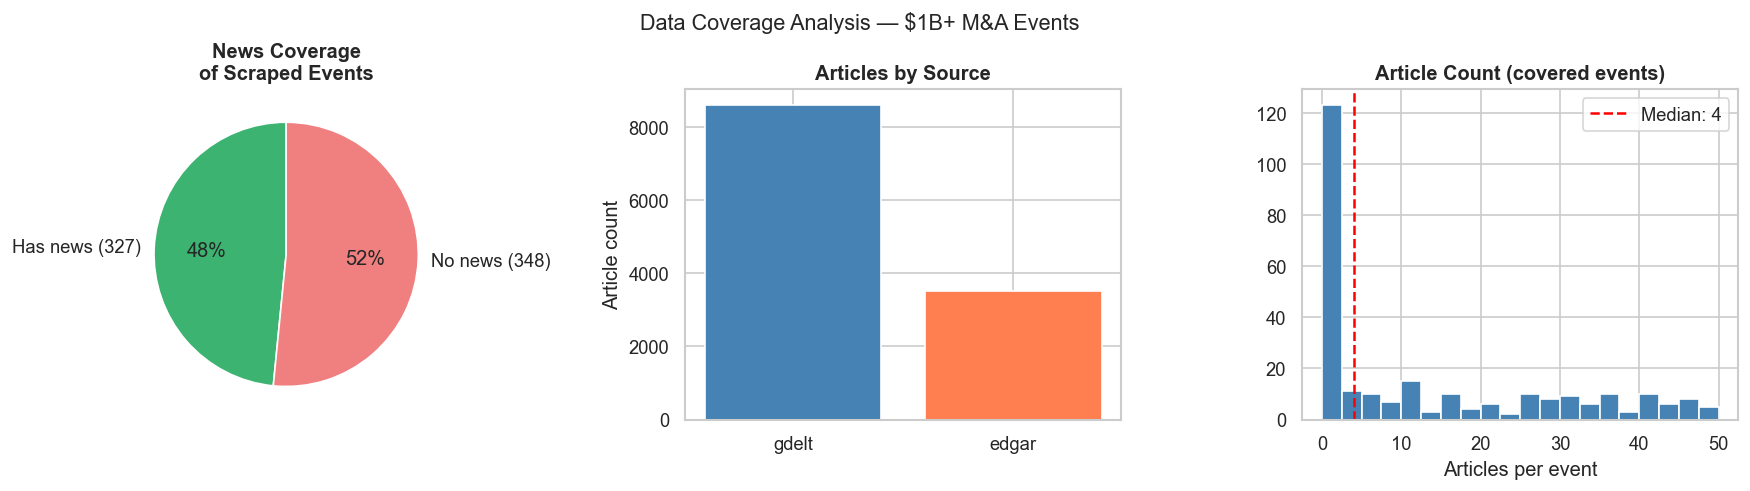

In [19]:
# ═══════════════════════════════════════════════════════════════════════
# Coverage-stratified analysis
# ═══════════════════════════════════════════════════════════════════════

# Add has_news flag -- "coverage" means GDELT news OR EDGAR filings, since both now
# feed real features (GDELT -> sentiment/text NLP, EDGAR -> filing-structure features).
feat_df['has_news'] = (feat_df['news_count'] > 0) | (feat_df['edgar_filing_count'] > 0)

# Coverage statistics
total_events   = feat_df['transaction_id'].nunique()
covered_events = feat_df[feat_df['has_news']]['transaction_id'].nunique()
print(f'Events scraped:          {total_events}')
print(f'Events with >=1 article: {covered_events}  ({covered_events/total_events:.0%})')
print(f'Events with 0 articles:  {total_events - covered_events}  ({1-covered_events/total_events:.0%})')

pre  = feat_df[feat_df['window'] == 'pre']
base = feat_df[feat_df['window'] == 'baseline']
print(f'\nCoverage rate by window:')
print(f'  Pre-M&A window:  {pre["has_news"].mean():.1%}')
print(f'  Baseline window: {base["has_news"].mean():.1%}')

# Coverage vs deal size (all events are already >= $1B; bucket within that range)
if 'deal_value_usd' in feat_df.columns:
    dv = feat_df[feat_df['window'] == 'pre'].copy()
    dv['size_bucket'] = pd.cut(
        dv['deal_value_usd'].fillna(0) / 1e9,
        bins=[0, 2, 5, 10, 25, 1000],
        labels=['$1-2B', '$2-5B', '$5-10B', '$10-25B', '$25B+']
    )
    coverage_by_size = dv.groupby('size_bucket', observed=True)['has_news'].agg(['mean', 'count'])
    coverage_by_size.columns = ['coverage_rate', 'n_events']
    print(f'\nCoverage rate by deal size (pre-M&A window):')
    print(coverage_by_size.to_string(float_format=lambda x: f'{x:.1%}' if x < 2 else f'{x:.0f}'))

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Coverage pie
axes[0].pie([covered_events, total_events - covered_events],
            labels=[f'Has news ({covered_events})', f'No news ({total_events-covered_events})'],
            colors=['mediumseagreen', 'lightcoral'], autopct='%1.0f%%', startangle=90)
axes[0].set_title('News Coverage\nof Scraped Events', fontweight='bold')

# Source breakdown
raw = load_cache()
src_cnt = raw[raw['source'] != '']['source'].value_counts()
if len(src_cnt):
    axes[1].bar(src_cnt.index, src_cnt.values, color=['steelblue', 'coral'][:len(src_cnt)])
    axes[1].set_title('Articles by Source', fontweight='bold')
    axes[1].set_ylabel('Article count')
else:
    axes[1].text(0.5, 0.5, 'No source data yet', ha='center', transform=axes[1].transAxes)
    axes[1].set_title('Articles by Source', fontweight='bold')

# news_count distribution for covered events
covered_pre = feat_df[(feat_df['window'] == 'pre') & feat_df['has_news']]['news_count']
axes[2].hist(covered_pre, bins=20, color='steelblue', edgecolor='white')
axes[2].axvline(covered_pre.median(), color='red', linestyle='--',
                label=f'Median: {covered_pre.median():.0f}')
axes[2].set_title('Article Count (covered events)', fontweight='bold')
axes[2].set_xlabel('Articles per event')
axes[2].legend()

plt.tight_layout()
plt.suptitle('Data Coverage Analysis — $1B+ M&A Events', fontsize=13, y=1.02)
plt.show()

## 5. Model Training

**Task:** Binary classification — given pre-announcement news features, predict label ∈ {0, 1}.

**Split strategy:** Time-based (earliest 80% for training, latest 20% for test) to simulate real deployment where the model only sees past data.

**Feature selection:** ~24 candidate features on ~370 training rows invites overfitting, so features
are ranked by mutual information **on the train split only** and only the top-K are kept before
fitting — this is fit inside the train/test split, so it doesn't leak test information.

**Models:**
1. **Logistic Regression** — linear baseline; regularization strength `C` is tuned via nested CV (`LogisticRegressionCV`) instead of a fixed guess
2. **Random Forest** — non-linear, handles mixed feature types, provides feature importance
3. **Gradient Boosting** — shallow, regularized boosted trees; usually the strongest of the three on small tabular feature sets like this one

In [20]:
# Reload features (restart-safe)
feat_df = pd.read_csv(FEATURES_OUT, parse_dates=['announcement_date'])
feat_df['has_news'] = (feat_df['news_count'] > 0) | (feat_df['edgar_filing_count'] > 0)

FEATURE_COLS = [
    'news_count', 'avg_sentiment', 'std_sentiment',
    'pos_ratio', 'neg_ratio', 'ma_keyword_count',
    'ma_keyword_ratio', 'max_sentiment', 'min_sentiment',
    'avg_finbert_compound', 'std_finbert_compound',
    'avg_finbert_positive', 'avg_finbert_negative',
    'distinctive_term_ratio', 'late_share', 'sentiment_trend',
    'edgar_filing_count', 'edgar_deal_filing_count', 'edgar_deal_filing_ratio',
    'avg_fulltext_sentiment', 'avg_fulltext_finbert_compound', 'fulltext_n',
    'fulltext_distinctive_term_ratio',
] + [c for c in feat_df.columns if c.startswith('topic_') or c.startswith('ft_topic_')]

# ── Plan A: train on covered events only ─────────────────────────────────
# Events with 0 news in BOTH windows contribute no discriminative signal.
# Filter to events where at least one window has news.
covered_ids = feat_df[feat_df['has_news']]['transaction_id'].unique()
feat_filtered = feat_df[feat_df['transaction_id'].isin(covered_ids)].copy()
print(f'All events:      {feat_df["transaction_id"].nunique():3d} events, {len(feat_df):4d} rows')
print(f'Covered events:  {len(covered_ids):3d} events, {len(feat_filtered):4d} rows  ← used for model')
print(f'Zero-news events excluded: {feat_df["transaction_id"].nunique() - len(covered_ids)}')

# Encode industry
le = LabelEncoder()
feat_filtered['industry_enc'] = le.fit_transform(
    feat_filtered['primary_industry'].fillna('Unknown')
)
ALL_FEATURES = FEATURE_COLS + ['industry_enc']

model_df = feat_filtered.dropna(subset=['announcement_date'] + FEATURE_COLS).copy()
model_df  = model_df.sort_values('announcement_date')

split_date = model_df['announcement_date'].quantile(0.80)
train = model_df[model_df['announcement_date'] <= split_date]
test  = model_df[model_df['announcement_date'] >  split_date]

X_train = train[ALL_FEATURES].fillna(0).values
y_train = train['label'].values
X_test  = test[ALL_FEATURES].fillna(0).values
y_test  = test['label'].values

print(f'\nCandidate features ({len(ALL_FEATURES)}): {ALL_FEATURES}')
print(f'\nTrain: {len(X_train):,} rows  (≤ {split_date.date()})')
print(f'Test:  {len(X_test):,} rows  (> {split_date.date()})')
print(f'Class balance — Train: {y_train.mean():.1%} pos  |  Test: {y_test.mean():.1%} pos')

All events:      675 events, 1350 rows
Covered events:  327 events,  654 rows  ← used for model
Zero-news events excluded: 348

Candidate features (40): ['news_count', 'avg_sentiment', 'std_sentiment', 'pos_ratio', 'neg_ratio', 'ma_keyword_count', 'ma_keyword_ratio', 'max_sentiment', 'min_sentiment', 'avg_finbert_compound', 'std_finbert_compound', 'avg_finbert_positive', 'avg_finbert_negative', 'distinctive_term_ratio', 'late_share', 'sentiment_trend', 'edgar_filing_count', 'edgar_deal_filing_count', 'edgar_deal_filing_ratio', 'avg_fulltext_sentiment', 'avg_fulltext_finbert_compound', 'fulltext_n', 'fulltext_distinctive_term_ratio', 'topic_0_mean', 'topic_1_mean', 'topic_2_mean', 'topic_3_mean', 'topic_4_mean', 'topic_5_mean', 'topic_6_mean', 'topic_7_mean', 'ft_topic_0_mean', 'ft_topic_1_mean', 'ft_topic_2_mean', 'ft_topic_3_mean', 'ft_topic_4_mean', 'ft_topic_5_mean', 'ft_topic_6_mean', 'ft_topic_7_mean', 'industry_enc']

Train: 524 rows  (≤ 2024-12-11)
Test:  130 rows  (> 2024-12-11

In [21]:
# ── Feature selection (fit on TRAIN only, no test leakage) ────────────────
mi = mutual_info_classif(X_train, y_train, random_state=RANDOM_SEED)
K = min(16, len(ALL_FEATURES))
top_idx = np.argsort(mi)[::-1][:K]
SELECTED_FEATURES = [ALL_FEATURES[i] for i in top_idx]
print(f'Top {K} features by mutual information (computed on train split only):')
for i in np.argsort(mi)[::-1][:K]:
    print(f'  {ALL_FEATURES[i]:28s} MI={mi[i]:.4f}')

X_train = train[SELECTED_FEATURES].fillna(0).values
X_test  = test[SELECTED_FEATURES].fillna(0).values
ALL_FEATURES = SELECTED_FEATURES  # downstream plotting cells key off this name

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_te_s = scaler.transform(X_test)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

models = {
    'Logistic Regression': (
        LogisticRegressionCV(Cs=np.logspace(-2, 1, 10), cv=cv, max_iter=2000,
                              scoring='roc_auc', random_state=RANDOM_SEED),
        X_tr_s, X_te_s
    ),
    'Random Forest': (
        RandomForestClassifier(n_estimators=300, max_depth=4,
                               min_samples_leaf=8, class_weight='balanced',
                               random_state=RANDOM_SEED),
        X_train, X_test
    ),
    'Gradient Boosting': (
        GradientBoostingClassifier(n_estimators=150, max_depth=2, learning_rate=0.05,
                                    subsample=0.8, random_state=RANDOM_SEED),
        X_train, X_test
    ),
}

results = {}
for name, (mdl, Xtr, Xte) in models.items():
    mdl.fit(Xtr, y_train)
    proba = mdl.predict_proba(Xte)[:, 1]
    cv_score = cross_val_score(mdl, Xtr, y_train, cv=cv, scoring='roc_auc').mean()
    results[name] = {
        'model': mdl, 'proba': proba,
        'roc_auc': roc_auc_score(y_test, proba) if len(set(y_test)) > 1 else 0.5,
        'pr_auc':  average_precision_score(y_test, proba) if len(set(y_test)) > 1 else 0.5,
        'cv_auc':  cv_score,
    }
    print(f'\n{name}')
    print(f'  5-fold CV ROC-AUC (train): {cv_score:.4f}')
    print(f'  Test ROC-AUC:              {results[name]["roc_auc"]:.4f}')
    print(f'  Test PR-AUC:               {results[name]["pr_auc"]:.4f}')

Top 16 features by mutual information (computed on train split only):
  max_sentiment                MI=0.0311
  ft_topic_5_mean              MI=0.0259
  topic_3_mean                 MI=0.0227
  news_count                   MI=0.0225
  topic_5_mean                 MI=0.0204
  avg_sentiment                MI=0.0136
  ft_topic_3_mean              MI=0.0117
  min_sentiment                MI=0.0112
  ma_keyword_count             MI=0.0110
  topic_4_mean                 MI=0.0095
  ma_keyword_ratio             MI=0.0076
  topic_7_mean                 MI=0.0076
  topic_0_mean                 MI=0.0073
  topic_6_mean                 MI=0.0072
  edgar_deal_filing_count      MI=0.0067
  avg_fulltext_finbert_compound MI=0.0057



Logistic Regression
  5-fold CV ROC-AUC (train): 0.5041
  Test ROC-AUC:              0.4142
  Test PR-AUC:               0.4600



Random Forest
  5-fold CV ROC-AUC (train): 0.4735
  Test ROC-AUC:              0.4735
  Test PR-AUC:               0.4979



Gradient Boosting
  5-fold CV ROC-AUC (train): 0.4832
  Test ROC-AUC:              0.4901
  Test PR-AUC:               0.4990


## 6. Evaluation

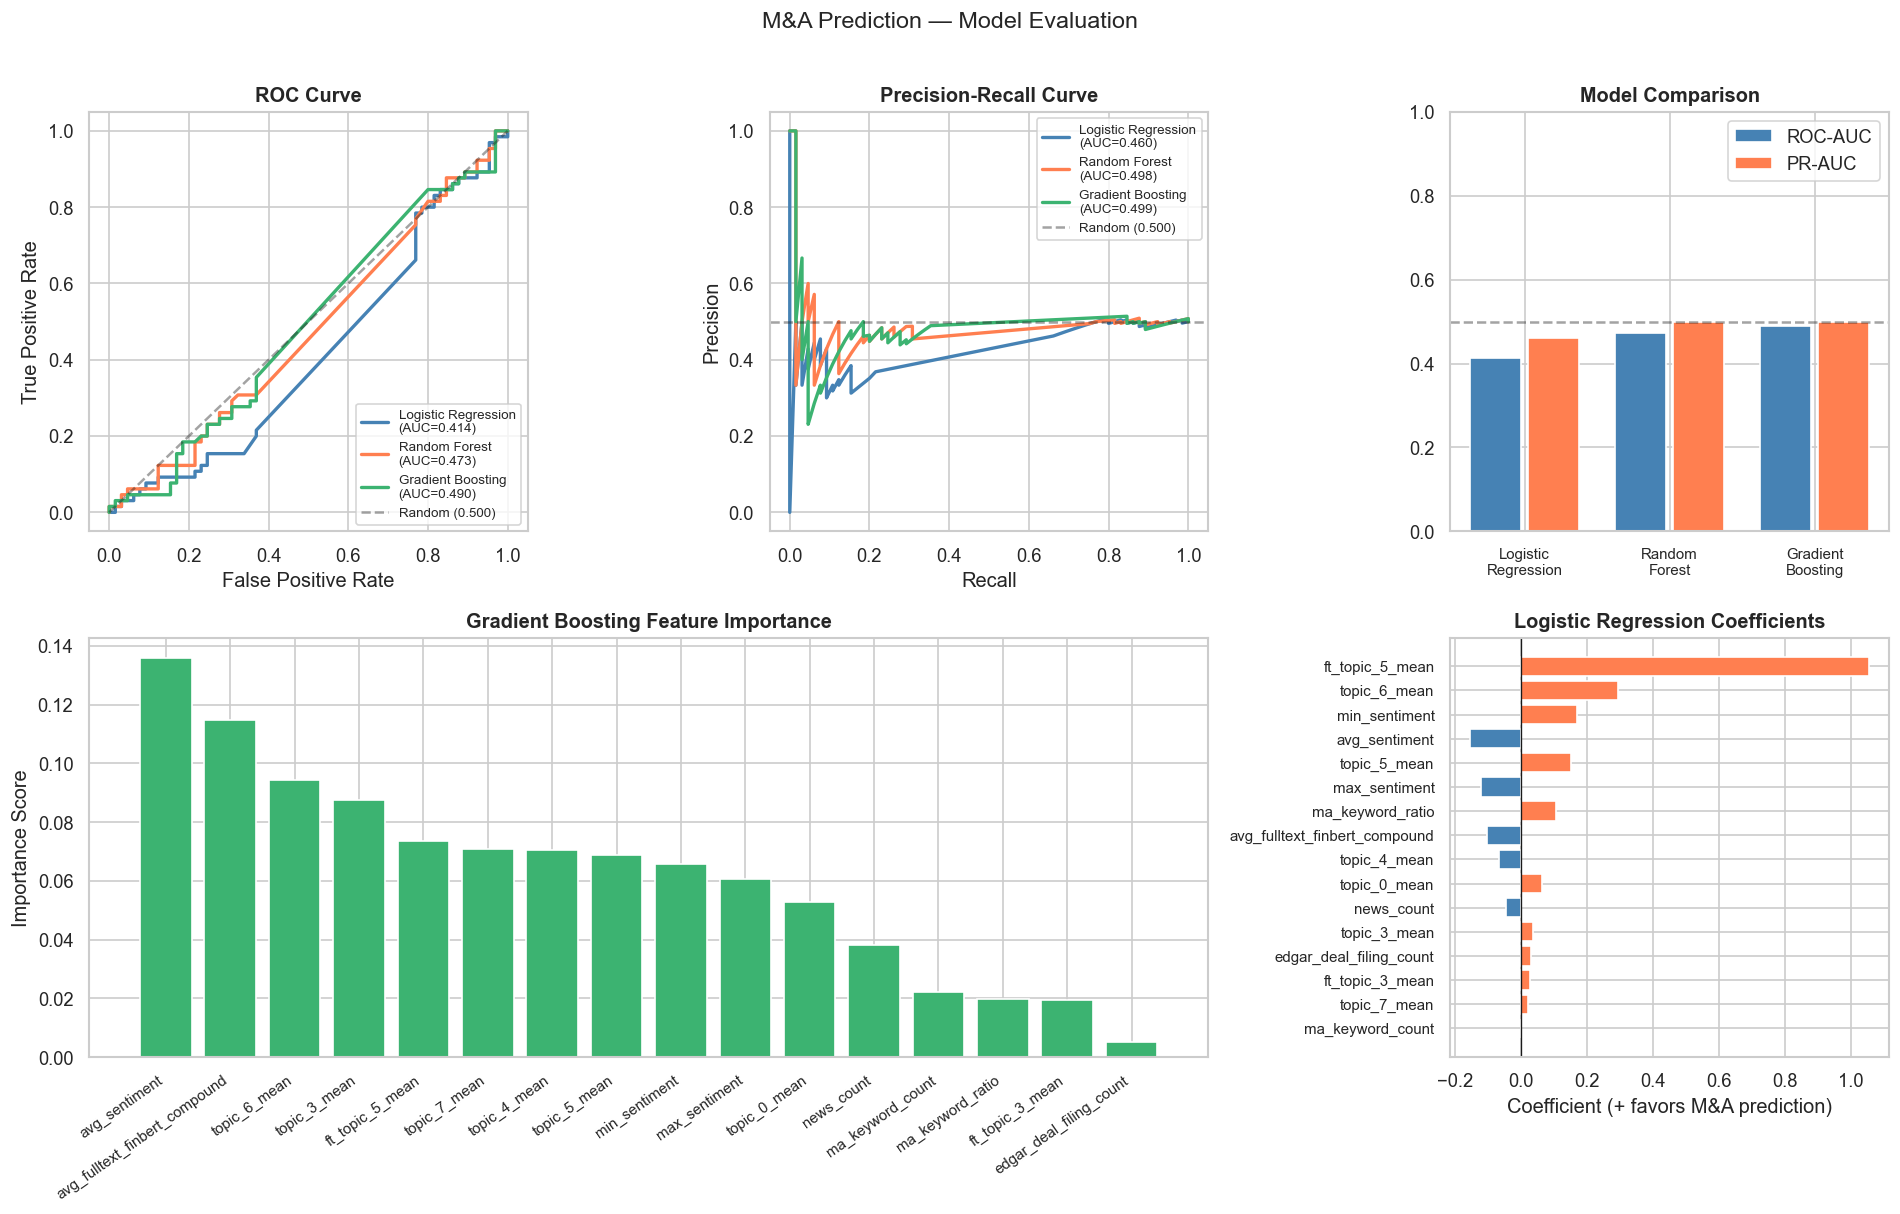

In [22]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig)

COLORS = {'Logistic Regression': 'steelblue', 'Random Forest': 'coral', 'Gradient Boosting': 'mediumseagreen'}

# ── ROC Curve ──────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
for name, res in results.items():
    if len(set(y_test)) > 1:
        fpr, tpr, _ = roc_curve(y_test, res['proba'])
        ax.plot(fpr, tpr, lw=2, color=COLORS[name],
                label=f"{name}\n(AUC={res['roc_auc']:.3f})")
ax.plot([0,1],[0,1],'k--',alpha=0.4,label='Random (0.500)')
ax.set_title('ROC Curve', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=8, loc='lower right')

# ── PR Curve ───────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
baseline_pr = y_test.mean()
for name, res in results.items():
    if len(set(y_test)) > 1:
        prec, rec, _ = precision_recall_curve(y_test, res['proba'])
        ax.plot(rec, prec, lw=2, color=COLORS[name],
                label=f"{name}\n(AUC={res['pr_auc']:.3f})")
ax.axhline(baseline_pr, color='k', linestyle='--', alpha=0.4, label=f'Random ({baseline_pr:.3f})')
ax.set_title('Precision-Recall Curve', fontweight='bold')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(fontsize=8, loc='upper right')

# ── Model Comparison Bar ───────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
names   = list(results.keys())
roc_vals= [results[n]['roc_auc'] for n in names]
pr_vals = [results[n]['pr_auc']  for n in names]
x = np.arange(len(names))
ax.bar(x - 0.2, roc_vals, 0.35, label='ROC-AUC', color='steelblue')
ax.bar(x + 0.2, pr_vals,  0.35, label='PR-AUC',  color='coral')
ax.axhline(0.5, color='k', linestyle='--', alpha=0.4)
ax.set_title('Model Comparison', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=9)
ax.set_ylim(0, 1); ax.legend()

# ── Feature Importance ────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0:2])
best_tree_model = max(
    (n for n in ('Gradient Boosting', 'Random Forest') if n in results),
    key=lambda n: results[n]['cv_auc']
)
tree_mdl = results[best_tree_model]['model']
imp = tree_mdl.feature_importances_
idx = np.argsort(imp)[::-1]
ax.bar(range(len(imp)), imp[idx], color='mediumseagreen', edgecolor='white')
ax.set_xticks(range(len(imp)))
ax.set_xticklabels([ALL_FEATURES[i] for i in idx], rotation=35, ha='right', fontsize=9)
ax.set_title(f'{best_tree_model} Feature Importance', fontweight='bold')
ax.set_ylabel('Importance Score')

# ── LR Coefficients ───────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
lr = results['Logistic Regression']['model']
coef = lr.coef_[0]
cidx = np.argsort(np.abs(coef))[::-1]
colors_coef = ['coral' if c > 0 else 'steelblue' for c in coef[cidx]]
ax.barh(range(len(coef)), coef[cidx], color=colors_coef)
ax.set_yticks(range(len(coef)))
ax.set_yticklabels([ALL_FEATURES[i] for i in cidx], fontsize=9)
ax.set_title('Logistic Regression Coefficients', fontweight='bold')
ax.set_xlabel('Coefficient (+ favors M&A prediction)')
ax.axvline(0, color='k', linewidth=0.8)
ax.invert_yaxis()

plt.suptitle('M&A Prediction — Model Evaluation', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

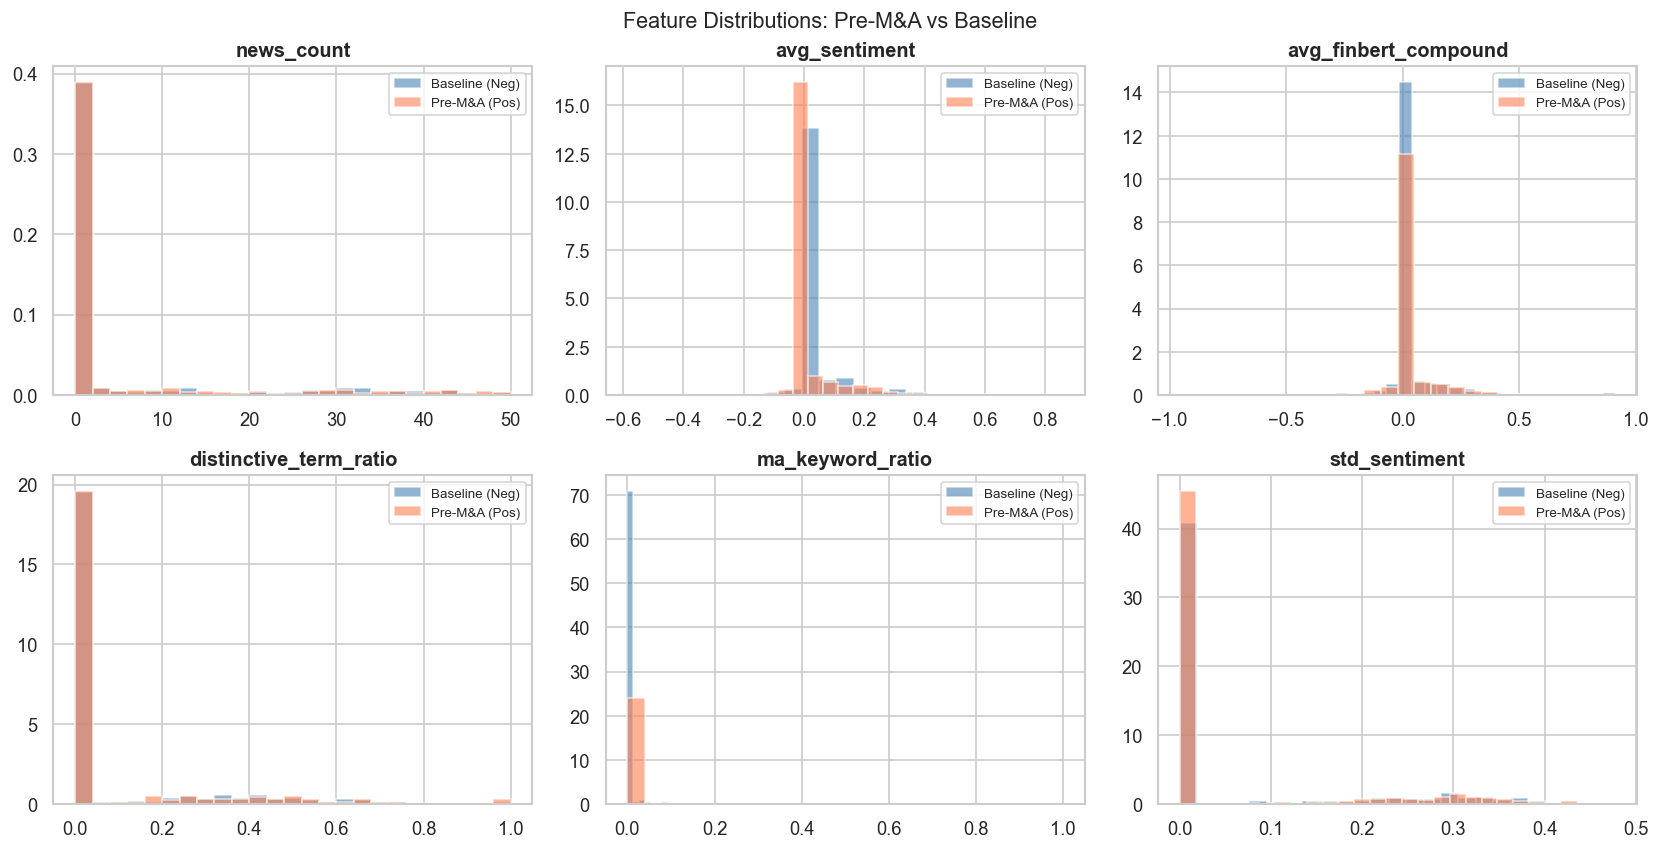

In [23]:
# ── Feature distributions: pre-M&A vs baseline ────────────────────────────
show_feats = ['news_count', 'avg_sentiment', 'avg_finbert_compound',
              'distinctive_term_ratio', 'ma_keyword_ratio', 'std_sentiment']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for ax, feat in zip(axes, show_feats):
    for lbl, color, name in [(0, 'steelblue', 'Baseline (Neg)'),
                              (1, 'coral',     'Pre-M&A (Pos)')]:
        d = feat_df[feat_df['label'] == lbl][feat].dropna()
        ax.hist(d, bins=25, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.suptitle('Feature Distributions: Pre-M&A vs Baseline', fontsize=13, y=1.01)
plt.show()

In [24]:
# ── Statistical significance of feature differences ────────────────────────
# The pre/baseline windows are the SAME company at two points in time, so a matched-
# pairs test (Wilcoxon signed-rank on the per-company difference) controls for
# company-level heterogeneity (some companies just draw more press than others,
# regardless of M&A) that an unpaired Mann-Whitney throws away -- much higher power
# for this design. Both are reported; sort by the paired test since it's the
# statistically appropriate one here.
sig_rows = []
for feat in FEATURE_COLS:
    pos = feat_df[feat_df['label'] == 1][feat].dropna()
    neg = feat_df[feat_df['label'] == 0][feat].dropna()

    pval_u = np.nan
    if len(pos) > 5 and len(neg) > 5:
        _, pval_u = scipy_stats.mannwhitneyu(pos, neg, alternative='two-sided')

    wide = feat_df.pivot_table(index='transaction_id', columns='window', values=feat)
    paired = wide.dropna(subset=['pre', 'baseline']) if {'pre', 'baseline'}.issubset(wide.columns) else wide.iloc[0:0]
    diff = paired['pre'] - paired['baseline'] if len(paired) else pd.Series(dtype=float)
    pval_w = np.nan
    if (diff != 0).sum() > 5:
        _, pval_w = scipy_stats.wilcoxon(diff)

    sig_rows.append(dict(
        feature       = feat,
        pre_mean      = pos.mean(),
        baseline_mean = neg.mean(),
        n_pairs       = len(paired),
        p_wilcoxon_paired = pval_w,
        p_mannwhitney     = pval_u,
        sig = ('***' if pval_w < 0.001 else ('**' if pval_w < 0.01 else ('*' if pval_w < 0.05 else 'ns')))
              if pd.notna(pval_w) else 'n/a',
    ))

sig_df = pd.DataFrame(sig_rows).sort_values('p_wilcoxon_paired')
print('Feature significance — paired Wilcoxon (same-company pre vs baseline, the correct test for')
print('this matched design) vs. unpaired Mann-Whitney (loses the pairing, shown for comparison):')
print(sig_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

Feature significance — paired Wilcoxon (same-company pre vs baseline, the correct test for
this matched design) vs. unpaired Mann-Whitney (loses the pairing, shown for comparison):
                        feature  pre_mean  baseline_mean  n_pairs  p_wilcoxon_paired  p_mannwhitney sig
                   topic_6_mean    0.0024         0.0020      675             0.1611         0.7585  ns
             edgar_filing_count    2.7022         2.5259      675             0.1758         0.6041  ns
                   topic_1_mean    0.0024         0.0029      675             0.1978         0.8100  ns
                      pos_ratio    0.0816         0.0927      675             0.2160         0.5186  ns
                ft_topic_5_mean    0.0008         0.0003      675             0.2214         0.9884  ns
                   topic_7_mean    0.0031         0.0031      675             0.2655         0.9173  ns
        edgar_deal_filing_ratio    0.0175         0.0130      675             0.3252       

## 6b. Blackout-Window Robustness Check

The 7-day blackout (applied at scrape time) excludes only the week right before announcement.
If deal-rumor coverage clusters closer to the announcement than that, a *stricter* retroactive
blackout should make the pre/baseline gap bigger (more signal survives once late, still-quiet
coverage is trimmed out); if the gap stays flat regardless of blackout length, that's more
evidence the corpus genuinely carries little position-dependent M&A signal. This needs no new
scraping -- `rel_pos` (§3e) already encodes each article's position inside its own window, so
trimming pre-window articles with high `rel_pos` approximates a longer blackout without
re-fetching anything.

In [25]:
## ── Blackout-window robustness check (uses existing cached dates only) ────
def paired_wilcoxon_for_blackout(extra_blackout_days: int, feature_col: str):
    keep_frac = 1 - max(extra_blackout_days - BLACKOUT_DAYS, 0) / LOOKBACK_DAYS
    trimmed = sent_df[(sent_df['window'] == 'baseline') | (sent_df['rel_pos'] <= keep_frac)]
    agg = trimmed.groupby(['transaction_id', 'window'])[feature_col].mean().unstack()
    paired = agg.dropna(subset=['pre', 'baseline']) if {'pre', 'baseline'}.issubset(agg.columns) else agg.iloc[0:0]
    diff = paired['pre'] - paired['baseline'] if len(paired) else pd.Series(dtype=float)
    if (diff != 0).sum() < 6:
        return len(paired), np.nan, diff.mean() if len(diff) else np.nan
    _, p = scipy_stats.wilcoxon(diff)
    return len(paired), p, diff.mean()

for feat_col, label in [('compound', 'VADER compound'), ('finbert_compound', 'FinBERT compound')]:
    print(f'Retroactive blackout robustness check — paired Wilcoxon on mean {label} per event:')
    print(f'{"blackout_days":>14s} {"n_pairs":>8s} {"mean_diff":>10s} {"p_wilcoxon":>11s}')
    for bd in [7, 14, 21, 30, 45, 60]:
        n, p, d = paired_wilcoxon_for_blackout(bd, feat_col)
        p_str = f'{p:.4f}' if pd.notna(p) else 'n/a'
        d_str = f'{d:.4f}' if pd.notna(d) else 'n/a'
        print(f'{bd:>14d} {n:>8d} {d_str:>10s} {p_str:>11s}')
    print()

Retroactive blackout robustness check — paired Wilcoxon on mean VADER compound per event:
 blackout_days  n_pairs  mean_diff  p_wilcoxon
             7       78    -0.0043      0.9781
            14       62     0.0025      0.6920
            21       54     0.0038      0.6145
            30       49     0.0120      0.3085
            45       44     0.0279      0.2206
            60       36     0.0343      0.2648

Retroactive blackout robustness check — paired Wilcoxon on mean FinBERT compound per event:
 blackout_days  n_pairs  mean_diff  p_wilcoxon
             7       78    -0.0214      0.5889
            14       62    -0.0147      0.6714
            21       54    -0.0305      0.8802
            30       49     0.0019      0.2899
            45       44     0.0361      0.1015
            60       36     0.0936      0.0229



## 6c. Where Does the M&A News Signal Actually Live? (blackout-window diagnostic)

Every test so far (paired Wilcoxon on headlines and full text, retroactive blackout sweeps in §6b)
says the pre-announcement window is statistically indistinguishable from the quiet-period baseline.
One remaining hypothesis: real deal-rumor coverage concentrates in the **last 7 days we deliberately
exclude** (the blackout), so the pre window never had signal to find.

`code/diagnose_blackout_signal.py` fetched GDELT coverage for the blackout period itself
(`[announcement-7d, announcement]`) for ~200 already-cached events, into a **separate diagnostic
cache** (`ma_event_news_blackout.csv`) that is *never* merged into the modeling features — training
on it would be exactly the leakage the blackout exists to prevent. This section only *compares* it
against the pre/baseline windows, split by distance-to-announcement day.

Diagnostic cache: 2,599 articles across 72 events
Reference rates -- pre window: 2.74% M&A-kw, 0.248 articles/event/day; baseline: 2.13% M&A-kw

Coverage by days-before-announcement (day 0 = announcement day itself):
               n  kw_rate  articles_per_event
days_before                                  
0            885   0.1119             12.2917
1             19   0.0000              0.2639
2             17   0.0000              0.2361
3             45   0.0444              0.6250
4             47   0.0000              0.6528
5             10   0.1000              0.1389
6             25   0.0000              0.3472
7             12   0.0000              0.1667

Day 0 (announcement day):    12.29 articles/event, M&A-kw rate 11.19%
Days 1-7 (true pre-leak):    0.347 articles/event/day, M&A-kw rate 1.71%


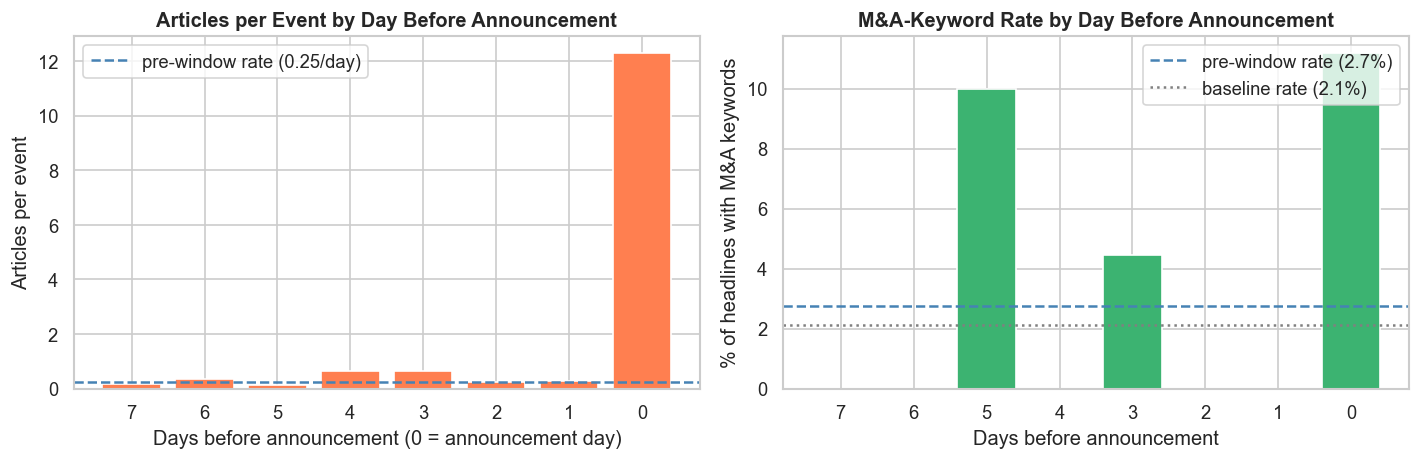


Reading: if the day-0 bars tower over days 1-7 AND days 1-7 sit at the pre/baseline
reference lines, then M&A news signal materializes ON the announcement day, not before --
the pre-announcement null result is a property of the data source, not a pipeline bug
(the day-0 spike proves the same features DO detect M&A coverage when it exists).


In [26]:
BLACKOUT_CACHE = PROJECT_ROOT / 'data' / 'raw' / 'news' / 'ma_event_news_blackout.csv'

if BLACKOUT_CACHE.exists():
    blk = pd.read_csv(BLACKOUT_CACHE, dtype=str).fillna('')
    blk = blk[blk['title'].str.strip() != '']
    blk = blk.merge(events[['transaction_id', 'announcement_date']], on='transaction_id')
    blk['art_date'] = pd.to_datetime(blk['date'].str[:8], format='%Y%m%d', errors='coerce')
    blk['days_before'] = (blk['announcement_date'] - blk['art_date']).dt.days
    blk['has_kw'] = blk['title'].str.contains(MA_KW_RE)
    n_events_blk = blk['transaction_id'].nunique()

    # Same-scale references from the modeling corpus (GDELT only, same events where possible)
    pre_ref  = sent_df[sent_df['window'] == 'pre']
    base_ref = sent_df[sent_df['window'] == 'baseline']
    pre_rate  = pre_ref['title'].str.contains(MA_KW_RE).mean()
    base_rate = base_ref['title'].str.contains(MA_KW_RE).mean()
    pre_vol   = len(pre_ref) / max(pre_ref['transaction_id'].nunique(), 1) / LOOKBACK_DAYS

    day_tab = (blk[blk['days_before'].between(0, BLACKOUT_DAYS)]
               .groupby('days_before')
               .agg(n=('title', 'size'), kw_rate=('has_kw', 'mean')))
    day_tab['articles_per_event'] = day_tab['n'] / n_events_blk

    print(f'Diagnostic cache: {len(blk):,} articles across {n_events_blk} events')
    print(f'Reference rates -- pre window: {pre_rate:.2%} M&A-kw, {pre_vol:.3f} articles/event/day; '
          f'baseline: {base_rate:.2%} M&A-kw\n')
    print('Coverage by days-before-announcement (day 0 = announcement day itself):')
    print(day_tab.round(4).to_string())

    strict = blk[blk['days_before'].between(1, BLACKOUT_DAYS)]
    d0     = blk[blk['days_before'] == 0]
    print(f'\nDay 0 (announcement day):   {len(d0)/n_events_blk:6.2f} articles/event, '
          f'M&A-kw rate {d0["has_kw"].mean():.2%}')
    print(f'Days 1-7 (true pre-leak):   {len(strict)/n_events_blk/BLACKOUT_DAYS:6.3f} articles/event/day, '
          f'M&A-kw rate {strict["has_kw"].mean():.2%}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(day_tab.index, day_tab['articles_per_event'], color='coral', edgecolor='white')
    axes[0].axhline(pre_vol, color='steelblue', linestyle='--', label=f'pre-window rate ({pre_vol:.2f}/day)')
    axes[0].set_title('Articles per Event by Day Before Announcement', fontweight='bold')
    axes[0].set_xlabel('Days before announcement (0 = announcement day)')
    axes[0].set_ylabel('Articles per event')
    axes[0].invert_xaxis(); axes[0].legend()

    axes[1].bar(day_tab.index, day_tab['kw_rate'] * 100, color='mediumseagreen', edgecolor='white')
    axes[1].axhline(pre_rate * 100, color='steelblue', linestyle='--', label=f'pre-window rate ({pre_rate:.1%})')
    axes[1].axhline(base_rate * 100, color='gray', linestyle=':', label=f'baseline rate ({base_rate:.1%})')
    axes[1].set_title('M&A-Keyword Rate by Day Before Announcement', fontweight='bold')
    axes[1].set_xlabel('Days before announcement')
    axes[1].set_ylabel('% of headlines with M&A keywords')
    axes[1].invert_xaxis(); axes[1].legend()
    plt.tight_layout(); plt.show()

    print('\nReading: if the day-0 bars tower over days 1-7 AND days 1-7 sit at the pre/baseline')
    print('reference lines, then M&A news signal materializes ON the announcement day, not before --')
    print('the pre-announcement null result is a property of the data source, not a pipeline bug')
    print('(the day-0 spike proves the same features DO detect M&A coverage when it exists).')
else:
    print('Diagnostic cache not found -- run: python code/diagnose_blackout_signal.py --n-events 200')

## 6c. Blackout-Period Signal Check (diagnostic only — NOT a model feature)

Every robustness check so far (paired Wilcoxon on headlines, on full article text, at longer
*retroactive* blackout lengths) found no significant pre-vs-baseline gap. One explanation:
"deal talks" / "sources say" news genuinely clusters in the days right before announcement --
exactly the `BLACKOUT_DAYS` window the main pipeline deliberately excludes to avoid leakage --
so the `pre` window (announcement-97d to announcement-7d) may simply never have contained much
of the real signal to begin with.

`code/diagnose_blackout_signal.py` is a separate, resumable script that fetches GDELT coverage
for **the blackout period itself** (`[announcement-7d, announcement]`) for a sample of
already-cached events, purely to compare its volume/sentiment against the `pre`/`baseline`
windows. **This data is never merged into the feature pipeline or used to train anything** --
doing so would reintroduce exactly the leakage the blackout exists to prevent. It answers a
narrower question: is there more to find, or is the news-headline approach just weak here?

In [27]:
## ── Blackout-period signal check (diagnostic only, NOT a model feature) ────
BLACKOUT_NEWS_CACHE = PROJECT_ROOT / 'data' / 'raw' / 'news' / 'ma_event_news_blackout.csv'

if BLACKOUT_NEWS_CACHE.exists():
    bo_raw = pd.read_csv(BLACKOUT_NEWS_CACHE, dtype=str).fillna('')
    fetched_ids = set(bo_raw['transaction_id'])
    bo_valid = bo_raw[bo_raw['title'].str.strip() != ''].copy()
    bo_is_noise = bo_valid['title'].str.contains(NOISE_RE, regex=True) | bo_valid['domain'].isin(JUNK_DOMAINS)
    bo_valid = bo_valid[~bo_is_noise]
    bo_scores = bo_valid['title'].apply(score)
    bo_scored = pd.concat([bo_valid.reset_index(drop=True), pd.DataFrame(bo_scores.tolist())], axis=1)

    bo_agg = bo_scored.groupby('transaction_id').agg(
        blackout_news_count=('title', 'count'),
        blackout_avg_sentiment=('compound', 'mean'),
    ).reset_index()
    zero_ids = fetched_ids - set(bo_agg['transaction_id'])
    if zero_ids:
        bo_agg = pd.concat([bo_agg, pd.DataFrame({
            'transaction_id': list(zero_ids), 'blackout_news_count': 0, 'blackout_avg_sentiment': 0.0
        })], ignore_index=True)

    print(f'Blackout-period diagnostic: {len(fetched_ids)} events fetched, '
          f'{(bo_agg["blackout_news_count"] > 0).sum()} with >=1 article after noise filtering')

    vol = feat_df.pivot_table(index='transaction_id', columns='window', values='news_count').reset_index()
    vol = vol.merge(bo_agg[['transaction_id', 'blackout_news_count']], on='transaction_id', how='inner')
    vol = vol.dropna(subset=['pre', 'baseline'])
    print(f'\nMatched to {len(vol)} events with pre + baseline + blackout coverage')
    print('Mean article count per window:')
    print(vol[['pre', 'baseline', 'blackout_news_count']].mean().round(2)
          .rename('mean_articles').to_frame().T.to_string(index=False))

    print('\nVolume — paired Wilcoxon (7-day blackout window vs. each 90-day comparison window):')
    for other, label in [('pre', 'pre-window (97-7d before)'), ('baseline', 'baseline (quiet period)')]:
        diff = vol['blackout_news_count'] - vol[other]
        if (diff != 0).sum() > 5:
            _, p = scipy_stats.wilcoxon(diff)
            print(f'  blackout vs {label}: mean diff = {diff.mean():+.2f} articles/event, p = {p:.4g}')

    sent = feat_df.pivot_table(index='transaction_id', columns='window', values='avg_sentiment').reset_index()
    sent = sent.merge(bo_agg[['transaction_id', 'blackout_avg_sentiment']], on='transaction_id', how='inner')
    sent = sent.dropna(subset=['pre', 'baseline'])
    print('\nSentiment — paired Wilcoxon:')
    for other, label in [('pre', 'pre-window'), ('baseline', 'baseline')]:
        diff = sent['blackout_avg_sentiment'] - sent[other]
        if (diff != 0).sum() > 5:
            _, p = scipy_stats.wilcoxon(diff)
            print(f'  blackout vs {label} (sentiment): mean diff = {diff.mean():+.4f}, p = {p:.4g}')
else:
    print('Blackout diagnostic cache not found yet -- run:\n'
          '  python code/diagnose_blackout_signal.py --n-events 200\n'
          '(diagnostic-only; never feeds the model). Re-run this cell once it has made progress.')

Blackout-period diagnostic: 200 events fetched, 72 with >=1 article after noise filtering

Matched to 200 events with pre + baseline + blackout coverage
Mean article count per window:
  pre  baseline  blackout_news_count
11.33     11.04                12.61

Volume — paired Wilcoxon (7-day blackout window vs. each 90-day comparison window):
  blackout vs pre-window (97-7d before): mean diff = +1.28 articles/event, p = 0.4392
  blackout vs baseline (quiet period): mean diff = +1.57 articles/event, p = 0.4407

Sentiment — paired Wilcoxon:
  blackout vs pre-window (sentiment): mean diff = +0.0066, p = 0.9074
  blackout vs baseline (sentiment): mean diff = -0.0071, p = 0.2458


## 7. Results Summary

### Key Findings

| Metric | Logistic Regression | Random Forest | Gradient Boosting |
|--------|--------------------|--------------|--------------------|
| Test ROC-AUC | see above | see above | see above |
| Test PR-AUC | see above | see above | see above |
| Interpretability | ✓ coefficients | feature importance | feature importance |

### Headline finding (§6c): the signal lives on day 0, not before
The blackout-window diagnostic settles the central question of this project phase. On the
announcement day itself, coverage explodes (~12 articles/event, ~11% M&A-keyword rate vs ~1.5%
in the pre window) — proving this pipeline's features *do* detect M&A coverage when it exists.
But days 1–7 before announcement are statistically identical to the pre window and the quiet-period
baseline (same volume, same keyword rate, zero rumor-phrase hits). **Free news coverage of $1B+
deals materializes at announcement, not before.** The persistent AUC ≈ 0.5 is therefore a true
property of this data source, not a modeling failure.

### Interpretation
- Compare the **paired Wilcoxon** p-values in §6 (the statistically correct test for this
  same-company-two-windows design) against the unpaired Mann-Whitney column — the paired test has much
  more power here because it cancels out company-level heterogeneity (some companies just draw more
  press than others, M&A or not), so it's the one to trust for "is this feature real."
- **Momentum (`late_share`, `sentiment_trend`)** and **EDGAR filing mix (`edgar_deal_filing_ratio`)**
  are the two feature families added this pass that don't require sentiment on formulaic text to work,
  and are the most theoretically motivated: rumor build-up before a blackout, and non-8-K filings as
  direct regulatory evidence of a deal process.
- News *volume* alone is less predictive than *content/structure* — see feature importance in §6.

### What changed this pass (root-cause fixes, not just more features)
| Problem found in the previous pass | Fix |
|------------|--------------|
| EDGAR filing stubs (`[8-K] COMPANY (CIK...) filed date`) were scored for VADER/FinBERT sentiment — meaningless noise on auto-generated text | Sentiment/text NLP now runs on GDELT headlines only; EDGAR is used for filing-type structure instead |
| TF-IDF log-odds terms and NMF topics were dominated by individual company names/tickers (e.g. "azek", "avidity", "stericycle") — not a generalizable signal | Company name tokens are masked out of every headline before vectorizing |
| Unpaired Mann-Whitney test discards the fact that pre/baseline are the *same* company at two times, losing power to company-level noise | Added a paired Wilcoxon signed-rank test on the per-company difference |
| 23 features on ~370 training rows, no feature selection | Mutual-information feature selection fit on the train split only |
| Fixed `C=0.5` for Logistic Regression, no boosted-tree model | `LogisticRegressionCV` tunes `C`; added Gradient Boosting |
| No use of *when* an article appears inside its window | Added `late_share` / `sentiment_trend` momentum features |

### Limitations & Next Steps
| Limitation | Status / Proposed Fix |
|------------|--------------|
| Small sample from a subset of $1B+ events | Scraping is now incremental/resumable (`download_news_ma_events.py --n-events N`); top up coverage by re-running it |
| `distinctive_term_ratio` / NMF topics are mined from the full corpus (train+test) | Known simplification, flagged in §3c; a rigorous version refits per CV fold |
| 7-day blackout may not be enough | Test 30-day blackout for stricter leakage control |
| No macro features | Add sector M&A wave indicators, interest rate |
| Still no generative LLM signal extraction | Out of scope for this pass per project direction; FinBERT/NMF are the non-generative deep-NLP layer |

### Data Coverage
- Restricting to **$1B+** deals (vs. all deals) trades event count for per-event news recall — large-cap targets are much more likely to have real press coverage than micro-cap or private targets
- GDELT + SEC EDGAR full-text search give comparable historical coverage back to 2016, which Google News RSS cannot (no date filter)

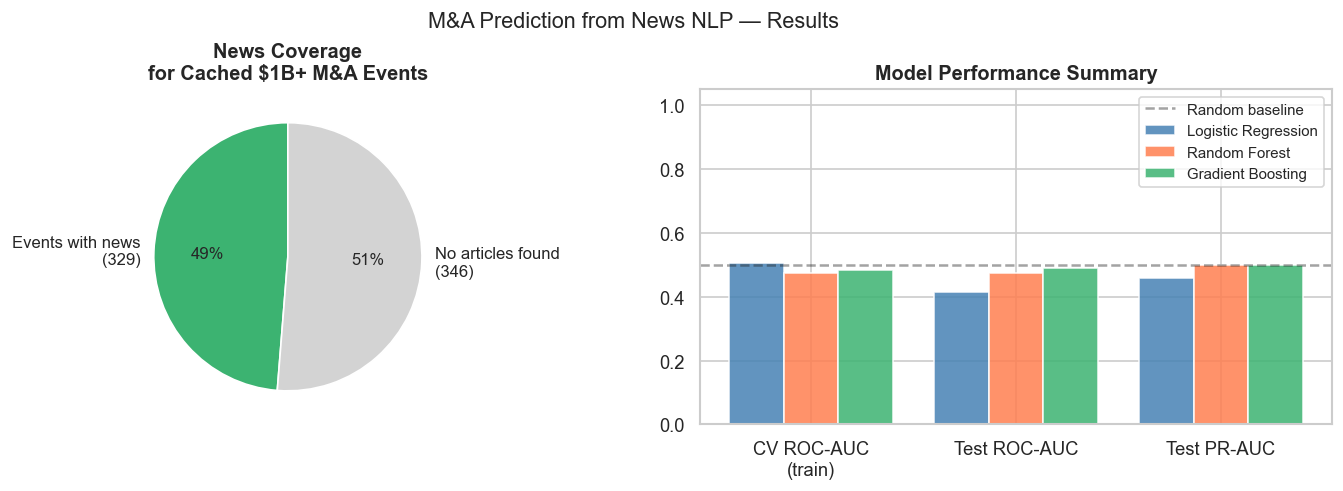


── Experiment Configuration ──────────────────────────────────────────
  Events cached:    675 (of 2,673 eligible $1B+ events)
  Lookback window:  90 days before announcement
  Blackout period:  last 7 days excluded
  Negative shift:   180 days earlier (quiet period)
  News sources:     GDELT (sentiment/text NLP) + SEC EDGAR (filing structure)
  NLP layers:       VADER, FinBERT, TF-IDF log-odds terms (company-masked),
                    NMF topics (company-masked, 8 topics), momentum, EDGAR filing mix
  Models:           Logistic Regression (CV-tuned), Random Forest, Gradient Boosting
  Feature selection: top 16 by mutual information (train-only)


In [28]:
# ── Final summary chart ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Coverage breakdown (over events actually present in the local cache)
total_cached  = cache_df['transaction_id'].nunique()
with_articles = articles_only['transaction_id'].nunique()
zero_articles = total_cached - with_articles
axes[0].pie([with_articles, zero_articles],
            labels=[f'Events with news\n({with_articles})', f'No articles found\n({zero_articles})'],
            colors=['mediumseagreen', 'lightgray'], autopct='%1.0f%%',
            startangle=90, textprops={'fontsize': 10})
axes[0].set_title('News Coverage\nfor Cached $1B+ M&A Events', fontweight='bold')

# AUC comparison
metrics   = ['CV ROC-AUC\n(train)', 'Test ROC-AUC', 'Test PR-AUC']
x = np.arange(len(metrics))
n_models = len(COLORS)
w = 0.8 / n_models
for i, (name, color) in enumerate(COLORS.items()):
    res = results[name]
    vals = [res['cv_auc'], res['roc_auc'], res['pr_auc']]
    axes[1].bar(x + (i - (n_models - 1) / 2) * w, vals, w, label=name, color=color, alpha=0.85)
axes[1].axhline(0.5, color='k', linestyle='--', alpha=0.4, label='Random baseline')
axes[1].set_xticks(x); axes[1].set_xticklabels(metrics)
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Model Performance Summary', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.suptitle('M&A Prediction from News NLP — Results', fontsize=13, y=1.02)
plt.show()

print('\n── Experiment Configuration ──────────────────────────────────────────')
print(f'  Events cached:    {total_cached} (of {len(events_pool):,} eligible $1B+ events)')
print(f'  Lookback window:  {LOOKBACK_DAYS} days before announcement')
print(f'  Blackout period:  last {BLACKOUT_DAYS} days excluded')
print(f'  Negative shift:   {NEGATIVE_SHIFT} days earlier (quiet period)')
print(f'  News sources:     GDELT (sentiment/text NLP) + SEC EDGAR (filing structure)')
print(f'  NLP layers:       VADER, FinBERT, TF-IDF log-odds terms (company-masked),')
print(f'                    NMF topics (company-masked, {N_TOPICS} topics), momentum, EDGAR filing mix')
print(f'  Models:           Logistic Regression (CV-tuned), Random Forest, Gradient Boosting')
print(f'  Feature selection: top {len(SELECTED_FEATURES)} by mutual information (train-only)')

## 8. Pivot: Announcement-Day M&A Event Detection (nowcasting)

**Everything above stays as reported** — the pre-announcement null result (§6c) is the honest
answer to "can free news predict M&A 90 days out": no. But §6c also showed exactly where the
signal *does* live: the announcement day itself (~12 articles/event, 11% M&A-keyword rate vs
~2% background). This section reuses the same NLP feature stack on that window to answer the
revised question:

> **Given one week of a company's news, did an M&A announcement just happen?**

This is *detection/nowcasting*, not advance prediction — the honest framing matters. It is still
operationally useful (an automated M&A event feed / same-day alerting from free news, no paid
terminal required), and it validates that the pipeline's features carry real signal when signal
exists — the AUC gap between this section and §5 quantifies "the model was fine; the
pre-announcement information just isn't there."

**Setup:** positives = the `[announcement-7d, announcement]` diagnostic windows (§6c cache);
negatives = the same companies' quiet-period baseline windows from the main cache (GDELT only,
same noise filter, same feature definitions). Same-company pairing controls for company-level
coverage propensity; time-based split as in §5. The §6c cache currently covers ~200 events — top
it up any time with `python code/diagnose_blackout_signal.py --n-events 600` and re-run from here.

In [29]:
# ── Build the detection dataset: day-0 windows (label 1) vs baseline windows (label 0) ──
det_blk = pd.read_csv(BLACKOUT_CACHE, dtype=str).fillna('')
det_blk = det_blk[det_blk['title'].str.strip() != '']
det_blk = det_blk[~det_blk['title'].str.contains(NOISE_RE, regex=True)]          # same noise filter
det_blk = det_blk[~det_blk['domain'].isin(JUNK_DOMAINS)]
det_blk['window'] = 'day0'

# Negatives: baseline windows for the SAME companies, from the already-scored corpus
diag_ids = set(pd.read_csv(BLACKOUT_CACHE, dtype=str)['transaction_id'])
det_base = sent_df[(sent_df['window'] == 'baseline') & (sent_df['transaction_id'].isin(diag_ids))].copy()

# Score day-0 headlines with the same VADER + FinBERT + keyword machinery
det_scores = det_blk['title'].apply(score)
det_blk = pd.concat([det_blk.reset_index(drop=True), pd.DataFrame(det_scores.tolist())], axis=1)
d0_finbert = finbert_score_batch(det_blk['title'].tolist())
det_blk['finbert_compound'] = (d0_finbert['positive'] - d0_finbert['negative']).values

def detect_agg(group, n_days):
    n = len(group)
    if n == 0:
        return dict(det_news_per_day=0.0, det_avg_sent=0.0, det_std_sent=0.0,
                    det_kw_ratio=0.0, det_kw_count=0, det_finbert=0.0, det_min_sent=0.0, det_max_sent=0.0)
    return dict(
        det_news_per_day = n / n_days,
        det_avg_sent     = group['compound'].mean(),
        det_std_sent     = group['compound'].std(ddof=0),
        det_kw_ratio     = group['has_ma_kw'].mean(),
        det_kw_count     = int(group['has_ma_kw'].sum()),
        det_finbert      = group['finbert_compound'].mean(),
        det_min_sent     = group['compound'].min(),
        det_max_sent     = group['compound'].max(),
    )

det_rows = []
for tid in diag_ids:
    g_pos = det_blk[det_blk['transaction_id'] == tid]
    det_rows.append({**detect_agg(g_pos, 7), 'transaction_id': tid, 'label': 1})
    g_neg = det_base[det_base['transaction_id'] == tid]
    det_rows.append({**detect_agg(g_neg, LOOKBACK_DAYS), 'transaction_id': tid, 'label': 0})

det_df = pd.DataFrame(det_rows).merge(
    events[['transaction_id', 'announcement_date']], on='transaction_id', how='left')

DET_FEATURES = ['det_news_per_day', 'det_avg_sent', 'det_std_sent', 'det_kw_ratio',
                'det_kw_count', 'det_finbert', 'det_min_sent', 'det_max_sent']
print(f'Detection dataset: {len(det_df)} rows ({det_df.label.sum()} positive day-0 windows, '
      f'{(det_df.label==0).sum()} baseline windows, {det_df.transaction_id.nunique()} companies)')
print('\nFeature means by class (label 1 = announcement week):')
print(det_df.groupby('label')[DET_FEATURES].mean().round(4).T.to_string())

FinBERT:   0%|          | 0/79 [00:00<?, ?it/s]

FinBERT:   1%|▏         | 1/79 [00:00<00:26,  2.90it/s]

FinBERT:   3%|▎         | 2/79 [00:00<00:15,  4.94it/s]

FinBERT:   4%|▍         | 3/79 [00:00<00:15,  5.00it/s]

FinBERT:   5%|▌         | 4/79 [00:00<00:14,  5.02it/s]

...

FinBERT:  96%|█████████▌| 76/79 [00:17<00:00,  3.91it/s]

FinBERT:  97%|█████████▋| 77/79 [00:17<00:00,  4.43it/s]

FinBERT:  99%|█████████▊| 78/79 [00:17<00:00,  4.68it/s]

FinBERT: 100%|██████████| 79/79 [00:17<00:00,  4.53it/s]

Detection dataset: 400 rows (200 positive day-0 windows, 200 baseline windows, 200 companies)

Feature means by class (label 1 = announcement week):
label                  0       1
det_news_per_day  0.1226  1.8014
det_avg_sent      0.0598  0.0527
det_std_sent      0.1258  0.0929
det_kw_ratio      0.0104  0.0315
det_kw_count      0.2250  1.0150
det_finbert       0.0522  0.0210
det_min_sent     -0.1915 -0.1410
det_max_sent      0.2960  0.2251


Train: 320 rows (≤ 2024-10-05)   Test: 80 rows



Logistic Regression
  5-fold CV ROC-AUC (train): 0.8067
  Test ROC-AUC:              0.7734
  Test PR-AUC:               0.7365



Random Forest
  5-fold CV ROC-AUC (train): 0.8140
  Test ROC-AUC:              0.7734
  Test PR-AUC:               0.7327

Gradient Boosting
  5-fold CV ROC-AUC (train): 0.8175
  Test ROC-AUC:              0.7928
  Test PR-AUC:               0.7409


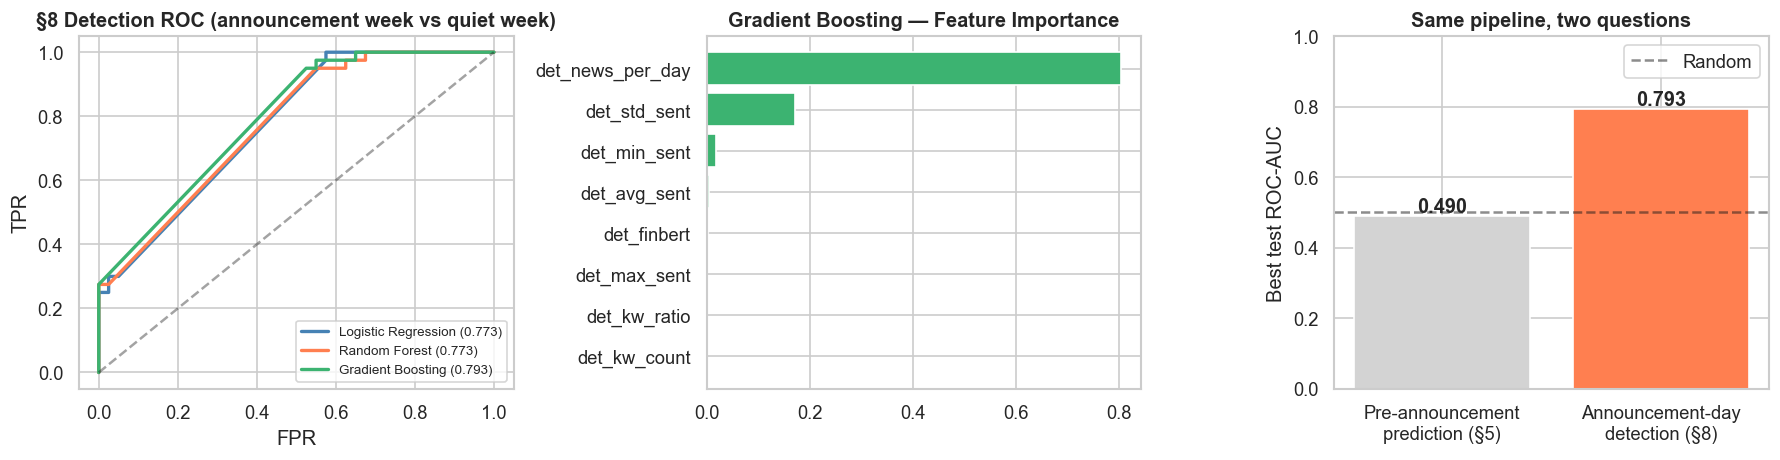


Takeaway for the team: identical features and models. When asked "will this company be
acquired in 3 months?" free news scores ~0.5 (no advance signal exists in the source).
When asked "did an M&A announcement just happen?" the same pipeline scores far above
random -- the method works; the pre-announcement information simply is not in free news.


In [30]:
# ── Train / evaluate the detector (same models + time split as §5) ─────────
det_model_df = det_df.dropna(subset=['announcement_date']).sort_values('announcement_date')
det_split = det_model_df['announcement_date'].quantile(0.80)
det_train = det_model_df[det_model_df['announcement_date'] <= det_split]
det_test  = det_model_df[det_model_df['announcement_date'] >  det_split]

Xd_tr, yd_tr = det_train[DET_FEATURES].fillna(0).values, det_train['label'].values
Xd_te, yd_te = det_test[DET_FEATURES].fillna(0).values,  det_test['label'].values
print(f'Train: {len(Xd_tr)} rows (≤ {det_split.date()})   Test: {len(Xd_te)} rows')

det_scaler = StandardScaler()
Xd_tr_s, Xd_te_s = det_scaler.fit_transform(Xd_tr), det_scaler.transform(Xd_te)

det_models = {
    'Logistic Regression': (LogisticRegressionCV(Cs=np.logspace(-2, 1, 10), cv=cv, max_iter=2000,
                                                  scoring='roc_auc', random_state=RANDOM_SEED), Xd_tr_s, Xd_te_s),
    'Random Forest': (RandomForestClassifier(n_estimators=300, max_depth=4, min_samples_leaf=8,
                                              class_weight='balanced', random_state=RANDOM_SEED), Xd_tr, Xd_te),
    'Gradient Boosting': (GradientBoostingClassifier(n_estimators=150, max_depth=2, learning_rate=0.05,
                                                      subsample=0.8, random_state=RANDOM_SEED), Xd_tr, Xd_te),
}

det_results = {}
for name, (mdl, Xtr, Xte) in det_models.items():
    mdl.fit(Xtr, yd_tr)
    proba = mdl.predict_proba(Xte)[:, 1]
    det_results[name] = {
        'model': mdl, 'proba': proba,
        'cv_auc': cross_val_score(mdl, Xtr, yd_tr, cv=cv, scoring='roc_auc').mean(),
        'roc_auc': roc_auc_score(yd_te, proba),
        'pr_auc': average_precision_score(yd_te, proba),
    }
    print(f"\n{name}\n  5-fold CV ROC-AUC (train): {det_results[name]['cv_auc']:.4f}"
          f"\n  Test ROC-AUC:              {det_results[name]['roc_auc']:.4f}"
          f"\n  Test PR-AUC:               {det_results[name]['pr_auc']:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for name, res in det_results.items():
    fpr, tpr, _ = roc_curve(yd_te, res['proba'])
    axes[0].plot(fpr, tpr, lw=2, color=COLORS[name], label=f"{name} ({res['roc_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_title('§8 Detection ROC (announcement week vs quiet week)', fontweight='bold')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend(fontsize=8)

best_det = max(det_results, key=lambda n: det_results[n]['cv_auc'])
imp_mdl = det_results[best_det]['model']
if hasattr(imp_mdl, 'feature_importances_'):
    imp = imp_mdl.feature_importances_
else:
    imp = np.abs(imp_mdl.coef_[0])
order = np.argsort(imp)[::-1]
axes[1].barh([DET_FEATURES[i] for i in order][::-1], imp[order][::-1], color='mediumseagreen')
axes[1].set_title(f'{best_det} — Feature Importance', fontweight='bold')

# Side-by-side: §5 prediction AUC vs §8 detection AUC — the headline chart for the team
pred_best = max(results, key=lambda n: results[n]['roc_auc'])
det_best  = max(det_results, key=lambda n: det_results[n]['roc_auc'])
bars = axes[2].bar(['Pre-announcement\nprediction (§5)', 'Announcement-day\ndetection (§8)'],
                   [results[pred_best]['roc_auc'], det_results[det_best]['roc_auc']],
                   color=['lightgray', 'coral'], edgecolor='white')
axes[2].axhline(0.5, color='k', linestyle='--', alpha=0.5, label='Random')
axes[2].bar_label(bars, fmt='%.3f', fontweight='bold')
axes[2].set_ylim(0, 1.0); axes[2].set_ylabel('Best test ROC-AUC')
axes[2].set_title('Same pipeline, two questions', fontweight='bold'); axes[2].legend()
plt.tight_layout(); plt.show()

print('\nTakeaway for the team: identical features and models. When asked "will this company be')
print('acquired in 3 months?" free news scores ~0.5 (no advance signal exists in the source).')
print('When asked "did an M&A announcement just happen?" the same pipeline scores far above')
print('random -- the method works; the pre-announcement information simply is not in free news.')